# Predicting Profitability in Logistics Operations Using ML

**Author:** Maryi Tatiana Palacios Giraldo  
**Course:** MSDS692_S40_Data Science Practicum

## Data Understanding

The dataset consists of import shipment records from a customs brokerage company. These records represent logistics operations, combining shipment tracking, financial performance, and operational metrics across multiple transport modes, including air, sea, and land.

The dataset contains 8,270 rows and 49 columns with detailed information on shipping routes, time-related variables (such as ETD, ETA, and ATA), financial indicators (including revenue, cost, and profit), and cargo characteristics such as weight, volume, and TEU. Additionally, it contains variables related to key entities involved in the process, such as suppliers, importers, and clients, providing a comprehensive view of the shipment lifecycle.

All information is handled with strict confidentiality and is used solely for academic purposes. No personal or sensitive client information is disclosed, and all results are presented at an aggregated level to ensure data privacy.

### Objective of the project

The objective of this project is to predict whether a shipment will be profitable using operational and shipment-level features available before execution.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
df = pd.read_excel(r'C:\Users\thati\OneDrive\Documentos\Regis\11_Practicum_1\Week_3\declaration.xlsx')

In [28]:
print(df.head())

  Declaration ID Cancel Trans Dec. Type Mode   Br Standalone  # Inv. Headers  \
0      B00001490      N   AIR       IMP  NCT  DEN          Y               1   
1      B00001491      N   TRK       IMP  NCT  SFO          Y               1   
2      B00001492      N   NaN       EXP  NaN  SFO          Y               0   
3      B00001493      N   SEA       IMP  CNT  IAH          Y               1   
4      B00001494      N   SEA       IMP  NCT  IAH          Y               1   

   # Inv. Lines Origin  ...          Job Opened  Revenue   WIP Total Income  \
0             1  CHBSL  ... 2025-12-01 15:13:00   235.00   NaN       235.00   
1             1  JPTYO  ... 2025-12-01 15:15:00      NaN   NaN          NaN   
2             0    NaN  ... 2025-12-01 15:16:00      NaN  3.28         3.28   
3             1  AOLAD  ... 2025-12-01 15:18:00   751.52   NaN       751.52   
4             1  BRSAO  ... 2025-12-01 16:01:00  1214.06   NaN      1214.06   

     Cost Accrual Total Expense Job Profit C

In [29]:
df.tail()

,Declaration ID,Cancel,Trans,Dec. Type,Mode,Br,Standalone,# Inv. Headers,# Inv. Lines,Origin,...,Job Opened,Revenue,WIP,Total Income,Cost,Accrual,Total Expense,Job Profit,Ctr Count,TEU
8265,S00001288,N,AIR,EXP,NCT,DEN,N,1,1,USPE4,...,2026-04-17 18:35:00,770.0,8.35,778.35,-356.35,NaN,-356.35,422.00,0,0.0
8266,S00001290,N,ROA,EXP,NaN,DEN,N,1,1,USBUF,...,2026-04-29 16:59:00,165.0,NaN,165.00,-8.35,NaN,-8.35,156.65,0,0.0
8267,S00001293,N,TRK,EXP,NCT,DEN,N,1,1,USPHN,...,2026-05-15 15:39:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
8268,S00001294,N,SEA,EXP,CNT,DEN,N,1,1,USHOU,...,2026-05-18 16:07:00,200.0,NaN,200.00,-12.75,NaN,-12.75,187.25,1,2.3
8269,S00001298,N,SEA,EXP,CNT,DEN,N,1,1,USOLS,...,2026-05-28 18:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0


In [30]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8270 entries, 0 to 8269
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Declaration ID     8270 non-null   object        
 1   Cancel             8270 non-null   object        
 2   Trans              7875 non-null   object        
 3   Dec. Type          8270 non-null   object        
 4   Mode               7824 non-null   object        
 5   Br                 8270 non-null   object        
 6   Standalone         8270 non-null   object        
 7   # Inv. Headers     8270 non-null   int64         
 8   # Inv. Lines       8270 non-null   int64         
 9   Origin             7804 non-null   object        
 10  Final Dest.        7920 non-null   object        
 11  Load               7793 non-null   object        
 12  Arrival            7941 non-null   object        
 13  Origin ETD         6649 non-null   datetime64[ns]
 14  Dest. ET

The dataset contains 8,270 records and 49 columns, with 14 numeric variables, 6 date fields, and 29 categorical ones. Variables such as WIP, Accrual, Job Sales Rep, and House have significant missing values (40–85%), limiting their usability. Additionally, some logistical tracking fields (e.g., ETD/ETA dates) show moderate gaps that I will be reviewing in the cleanning process.

In [31]:
df.describe()

,# Inv. Headers,# Inv. Lines,Origin ETD,Dest. ETA,Load ATD,Arrival ATA,Dec. Registered,Weight,Volume,Packs,Job Opened,Revenue,WIP,Total Income,Cost,Accrual,Total Expense,Job Profit,Ctr Count,TEU
count,8270.000000,8270.000000,6649,7613,7658,7653,8270,8270.000000,8270.000000,8270.00000,8270,6948.000000,1292.000000,8204.000000,8158.000000,1036.000000,8203.000000,8264.000000,8270.000000,8270.000000
mean,0.927207,8.696372,2026-02-16 13:12:42.538727680,2026-03-12 20:36:19.048995072,2026-02-15 07:01:23.677200384,2026-03-10 09:36:09.031752448,2026-02-25 22:33:59.354292736,9849.974870,24.667200,346.56058,2026-02-25 21:45:10.251511552,5966.974290,3002.420139,5526.287688,-4768.599712,-4505.491467,-5311.462344,213.908347,0.462273,0.715175
min,0.000000,0.000000,2020-01-22 00:00:00,2025-04-24 00:00:00,2025-01-25 00:00:00,2025-04-21 00:00:00,2025-12-01 14:28:00,0.000000,0.000000,0.00000,2025-10-30 17:08:00,30.000000,1.150000,3.280000,-215878.690000,-103629.810000,-216162.050000,-8642.950000,0.000000,0.000000
25%,1.000000,1.000000,2026-01-02 00:00:00,2026-01-22 00:00:00,2025-12-29 06:00:00,2026-01-20 00:00:00,2026-01-08 23:15:00,168.000000,0.000000,1.00000,2026-01-08 22:19:15,270.000000,9.950000,183.580000,-4378.920000,-7797.672500,-6899.800000,107.050000,0.000000,0.000000
50%,1.000000,1.000000,2026-02-17 00:00:00,2026-03-11 00:00:00,2026-02-14 00:00:00,2026-03-09 00:00:00,2026-02-24 23:40:30,1510.000000,0.000000,6.00000,2026-02-24 23:13:00,899.510000,9.950000,746.500000,-270.010000,-400.000000,-482.790000,150.000000,0.000000,0.000000
75%,1.000000,1.000000,2026-04-07 00:00:00,2026-05-01 00:00:00,2026-04-06 00:00:00,2026-04-29 00:00:00,2026-04-14 21:44:00,13525.500000,0.000000,128.00000,2026-04-14 21:35:15,7015.440000,7000.240000,7033.100000,-9.950000,-110.500000,-9.950000,253.000000,1.000000,1.000000
max,31.000000,9956.000000,2026-12-12 00:00:00,2028-04-29 00:00:00,2026-07-19 00:00:00,2026-08-23 00:00:00,2026-05-30 14:43:00,999999.999000,120000.000000,83457.00000,2026-05-30 14:43:00,216592.410000,88476.740000,216592.410000,5531.160000,15032.400000,0.020000,5211.040000,23.000000,52.000000
std,1.046285,183.019364,NaN,NaN,NaN,NaN,NaN,40497.682726,1360.841362,2478.98673,NaN,14027.022707,6446.257385,13200.980621,12929.197868,8368.710780,13119.693279,343.426552,0.885768,1.758033


In [32]:
df.columns

Index(['Declaration ID', 'Cancel', 'Trans', 'Dec. Type', 'Mode', 'Br',
       'Standalone', '# Inv. Headers', '# Inv. Lines', 'Origin', 'Final Dest.',
       'Load', 'Arrival', 'Origin ETD', 'Dest. ETA', 'Load ATD', 'Arrival ATA',
       'Dec. Registered', 'Supplier', 'Supplier Name', 'Importer',
       'Importer Name', 'House', 'Master', 'Vessel', 'Voy./Flt.', 'Weight',
       'Wt. UQ', 'Volume', 'Vol. UQ', 'Packs', 'Pack Type', 'BR', 'Dept',
       'Local Client', 'Local Client Name', 'Job Sales Rep', 'Job Operator',
       'Status', 'Job Opened', 'Revenue', 'WIP', 'Total Income', 'Cost',
       'Accrual', 'Total Expense', 'Job Profit', 'Ctr Count', 'TEU'],
      dtype='object')

In [33]:
df.duplicated().sum()

0

In [34]:
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_pct.sort_values(ascending=False)

Accrual              87.472793
WIP                  84.377267
House                51.692866
Job Sales Rep        49.830713
Vessel               39.842805
Origin ETD           19.600967
Revenue              15.985490
Pack Type            13.518742
Voy./Flt.            11.995163
Vol. UQ               9.600967
Dest. ETA             7.944377
Arrival ATA           7.460701
Load ATD              7.400242
Master                6.372430
Load                  5.767836
Supplier              5.719468
Supplier Name         5.719468
Origin                5.634825
Mode                  5.392987
Trans                 4.776300
Final Dest.           4.232164
Arrival               3.978235
Importer              3.446191
Importer Name         3.446191
Wt. UQ                2.406288
Cost                  1.354293
Total Expense         0.810157
Total Income          0.798065
Local Client Name     0.133011
Local Client          0.133011
Job Profit            0.072551
Job Opened            0.000000
Status  

Most operational variables show very low missing rates (<1%), indicating that core shipment information is consistently capture.

# Handling missing values

## Remove columns with a high number of missing values:

In [35]:
cols_drop = [
    'WIP', 'Accrual', 'House',
    'Job Sales Rep', 'Vessel',
    'Master', 'Vol. UQ', 'Voy./Flt.'
]

df = df.drop(columns=cols_drop)

Variables with extremely high missing rates or low analytical value were removed to improve data quality and reduce noise:

- WIP and Accrual: mostly missing (>85%), not reliable for modeling
- House, Master, Vessel, Voy./Flt. and Vol. UQ: not very relevant for the analysis

## Handling Categorical Variables with Unknown

In [36]:
cat_cols = [
    'Mode', 'Origin', 'Final Dest.', 'Supplier', 'Supplier Name',
    'Importer', 'Importer Name', 'Pack Type', 'Load', 'Local Client' , 'Local Client Name' ,
    'Wt. UQ', 'Trans', 'Arrival'
]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

Categorical variables were imputed using a placeholder value "Unknown":

- Preserves information about missing categories
- Prevents loss of records
- Standard practice for categorical imputation in logistics datasets

## Numerical variables with the mean

In [37]:
numeric_cols = ['Revenue', 'Cost', 'Total Expense', 'Total Income', 'Job Profit']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

Financial variables were imputed using the median to reduce the impact of outliers:

- Median is robust to extreme values (important due to high variance in revenue/cost)
- Maintains distribution integrity


In [38]:
df = df.dropna(subset=['Arrival ATA'])

Additionally, the Arrival ATA variable had very few missing values and was handled by removing incomplete records.

## Date Variables: Adjust Format

In [39]:

date_cols = [
    'Origin ETD', 'Dest. ETA',
    'Load ATD', 'Arrival ATA',
    'Dec. Registered', 'Job Opened'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


In [40]:

df['Origin ETD'] = df['Origin ETD'].fillna(df['Load ATD'])
df['Dest. ETA'] = df['Dest. ETA'].fillna(df['Arrival ATA'])


Missing date values were handled using logical imputation. For example, when the estimated departure date (ETD) was missing, it was replaced with the actual departure date (ATD), since both represent closely related shipment events. Similarly, missing estimated arrival dates (ETA) were replaced with actual arrival dates (ATA). This approach preserves temporal consistency while avoiding unnecessary data loss.

In [41]:
df.isnull().sum().sum()

35

In [42]:
cat_cols = [
    'Trans', 'Mode', 'Origin', 'Final Dest.', 'Load', 'Arrival',
    'Supplier', 'Supplier Name',
    'Importer', 'Importer Name',
    'Pack Type',
    'Dept', 'Local Client', 'Local Client Name',
    'Job Operator', 'Status',
    'Wt. UQ', 'Br',
]

In [43]:
for col in cat_cols:
    df[col] = df[col].astype('category')

Several variables originally stored as object type were identified as categorical variables representing discrete operational and logistical attributes within the shipment process. These include transportation mode, geographic origin and destination, suppliers, importers, operational status, and packaging types.

To support more effective exploratory analysis, these variables were converted to the category data type in pandas.

## Binary Variables

In [44]:
df['Cancel'] = df['Cancel'].map({'Y':1,'N':0})
df['Standalone'] = df['Standalone'].map({'Y':1,'N':0})

Converting to Categorical

In [45]:
cat_cols_final = [
    'Trans', 'Mode', 'Origin', 'Final Dest.', 'Load', 'Arrival',
    'Supplier', 'Supplier Name', 'Importer', 'Importer Name',
    'Pack Type', 'Dept', 'Local Client', 'Local Client Name',
    'Job Operator', 'Status', 'Wt. UQ', 'Br'
]

for col in cat_cols_final:
    if col in df.columns:
        df[col] = df[col].astype('category')

In addition to categorical transformations, binary variables were identified and encoded into numerical format to ensure compatibility with statistical analysis and potential predictive modeling tasks. Specifically, variables representing yes/no conditions were transformed into binary indicators.

In [46]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print(missing_counts)



Origin ETD    17
Load ATD      18
dtype: int64


In [47]:
df = df.dropna(subset=["Origin ETD", "Load ATD"])


A very small number of records (less than 0.3% of the dataset) still contained missing values in departure variables (Origin ETD and Load ATD). After reviewing these cases, it was determined that they represent inconsistent or incomplete shipment records. Given their minimal proportion and lack of reliability, these observations were removed to ensure data consistency and maintain the integrity of the modeling process.


In [48]:
df = df.rename(columns={

    '# Inv. Headers': 'Invoice Headers',
    '# Inv. Lines': 'Invoice Lines',

    'Wt. UQ': 'Weight Unit',
    'Vol. UQ': 'Volume Unit',

    'Trans': 'Transport Type',
    'Mode': 'Mode',
    'Br': 'Branch',

    'Dec. Type': 'Dec. Type',

    'Arrival': 'Arrival Port',
    'Origin': 'Origin Port',
    'Final Dest.': 'Final Destination',
    'Load': 'Load Port',

    'Voy./Flt.': 'Voyage/Flight',

    'Ctr Count': 'Container Count',

    'Job Opened': 'Job Opened',
    'Job Operator': 'Job Operator',

    'Local Client': 'Local Client',
    'Local Client Name': 'Local Client Name',

    'Supplier': 'Supplier',
    'Supplier Name': 'Supplier Name',

    'Importer': 'Importer',
    'Importer Name': 'Importer Name'
})

Column names were selectively standardized to improve readability during analysis.

In [49]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print(missing_counts)


Series([], dtype: int64)


The initial dataset contained missing values, inconsistent date formats, and variables that were not relevant to the objectives of this study. Data cleaning was performed to improve data quality and ensure consistency across shipment records. This process included handling missing values, converting date fields to appropriate formats, removing duplicate records, and standardizing variable types. The resulting dataset provided a reliable foundation for exploratory analysis and predictive modeling.

# EDA


Before developing predictive models, an exploratory data analysis (EDA) was conducted to better understand shipment characteristics, profitability patterns, and operational performance. The objective was to identify trends, relationships, and potential factors associated with shipment profitability and delays. The analysis was organized into three areas: Operational Activity, Financial Performance, and Operational Efficiency.

# 1. SHIPMENT CHARACTERISTICS

The first stage of the analysis focuses on operational activity. Understanding shipment volume, transportation modes, and branch workload provides important context regarding how logistics operations are distributed across the organization. These factors may indirectly influence both profitability and service performance.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1. Declarations processed per month

In [51]:

df["reg_month"] = df["Dec. Registered"].dt.to_period("M")
df["reg_year"] = df["Dec. Registered"].dt.year
df["reg_day"] = df["Dec. Registered"].dt.day

df["reg_month"] = df["Dec. Registered"].dt.to_period("M")
df["reg_year"] = df["Dec. Registered"].dt.year
df["reg_day"] = df["Dec. Registered"].dt.day


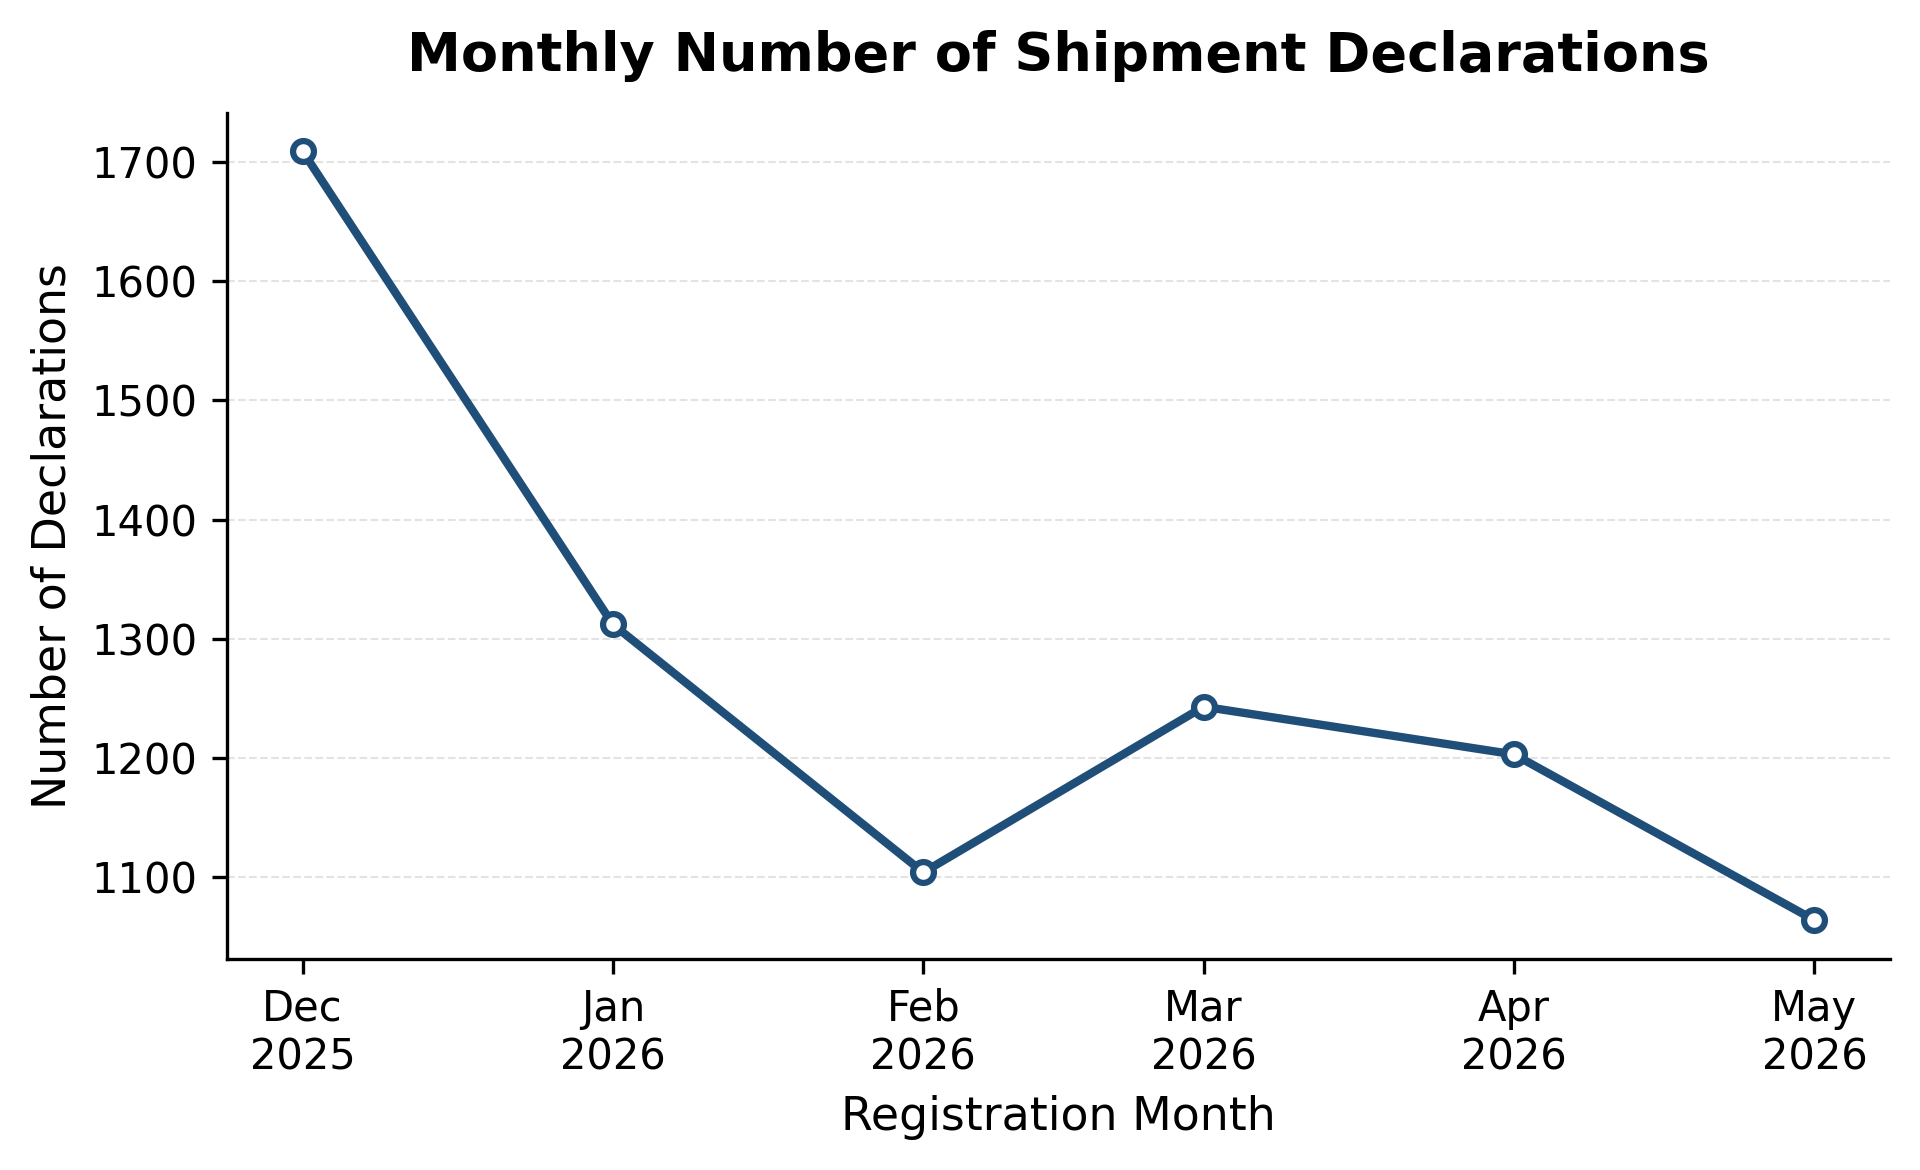

In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

monthly_decl = df.groupby("reg_month").size()

monthly_decl.index = monthly_decl.index.to_timestamp()

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

ax.plot(
    monthly_decl.index,
    monthly_decl.values,
    color="#1F4E79",
    linewidth=2,
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgewidth=1.5
)

ax.set_title(
    "Monthly Number of Shipment Declarations",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Registration Month", fontsize=11)
ax.set_ylabel("Number of Declarations", fontsize=11)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

This chart shows the number of declarations over time. We observe a peak in December, followed by a significant decline in early months, suggesting seasonal demand patterns. Although there is a partial recovery in March, the overall trend remains lower compared to the year-end peak.

## 1.2. Transport Type Distribution

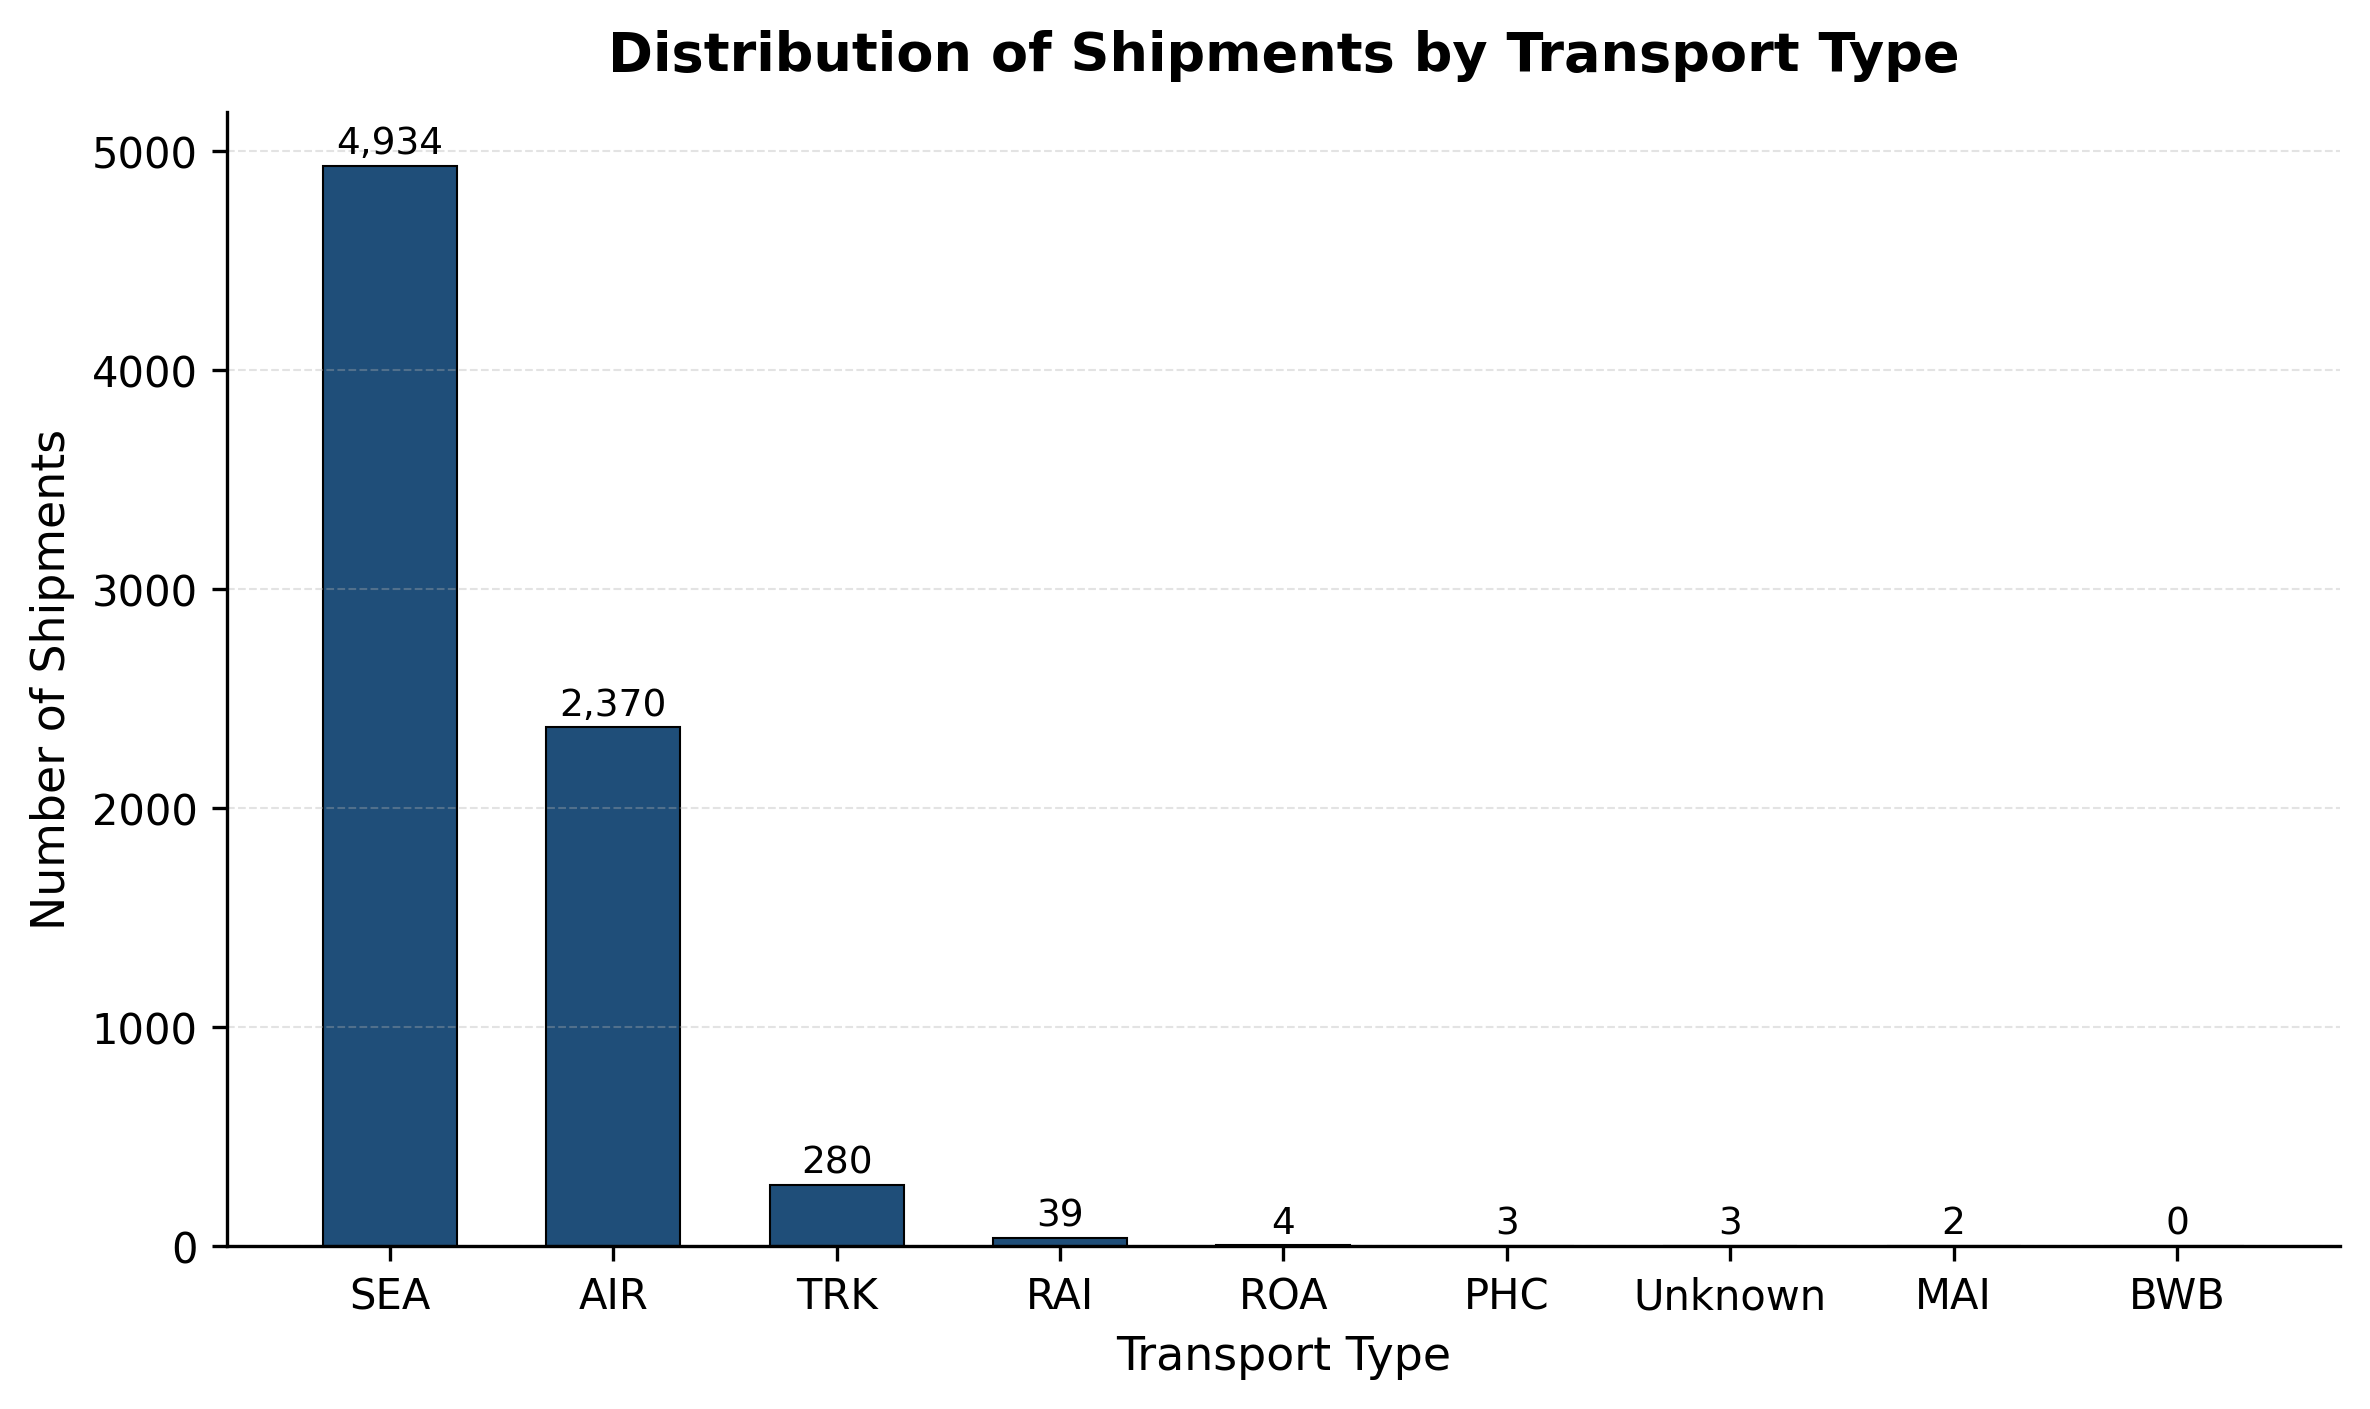

In [53]:
transport_counts = (
    df["Transport Type"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=300)

bars = ax.bar(
    transport_counts.index,
    transport_counts.values,
    color="#1F4E79",
    edgecolor="black",
    linewidth=0.5,
    width=0.6
)

ax.set_title(
    "Distribution of Shipments by Transport Type",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Transport Type", fontsize=11)
ax.set_ylabel("Number of Shipments", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.35)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

The transport type distribution shows a strong dominance of sea shipments, followed by air transport. Other modes contribute minimally to overall operations. This indicates a high dependency on specific transport types, which may introduce operational risks, particularly in modes prone to delays such as sea transport.

Transport Type Reference:

AIR – Air Transport  
SEA – Sea Transport  
TRK – Truck  
RAI – Rail  
ROA – Road  
MAI – Mail  
PHC – Hand Carry  

## 1.3. Branch Distribution

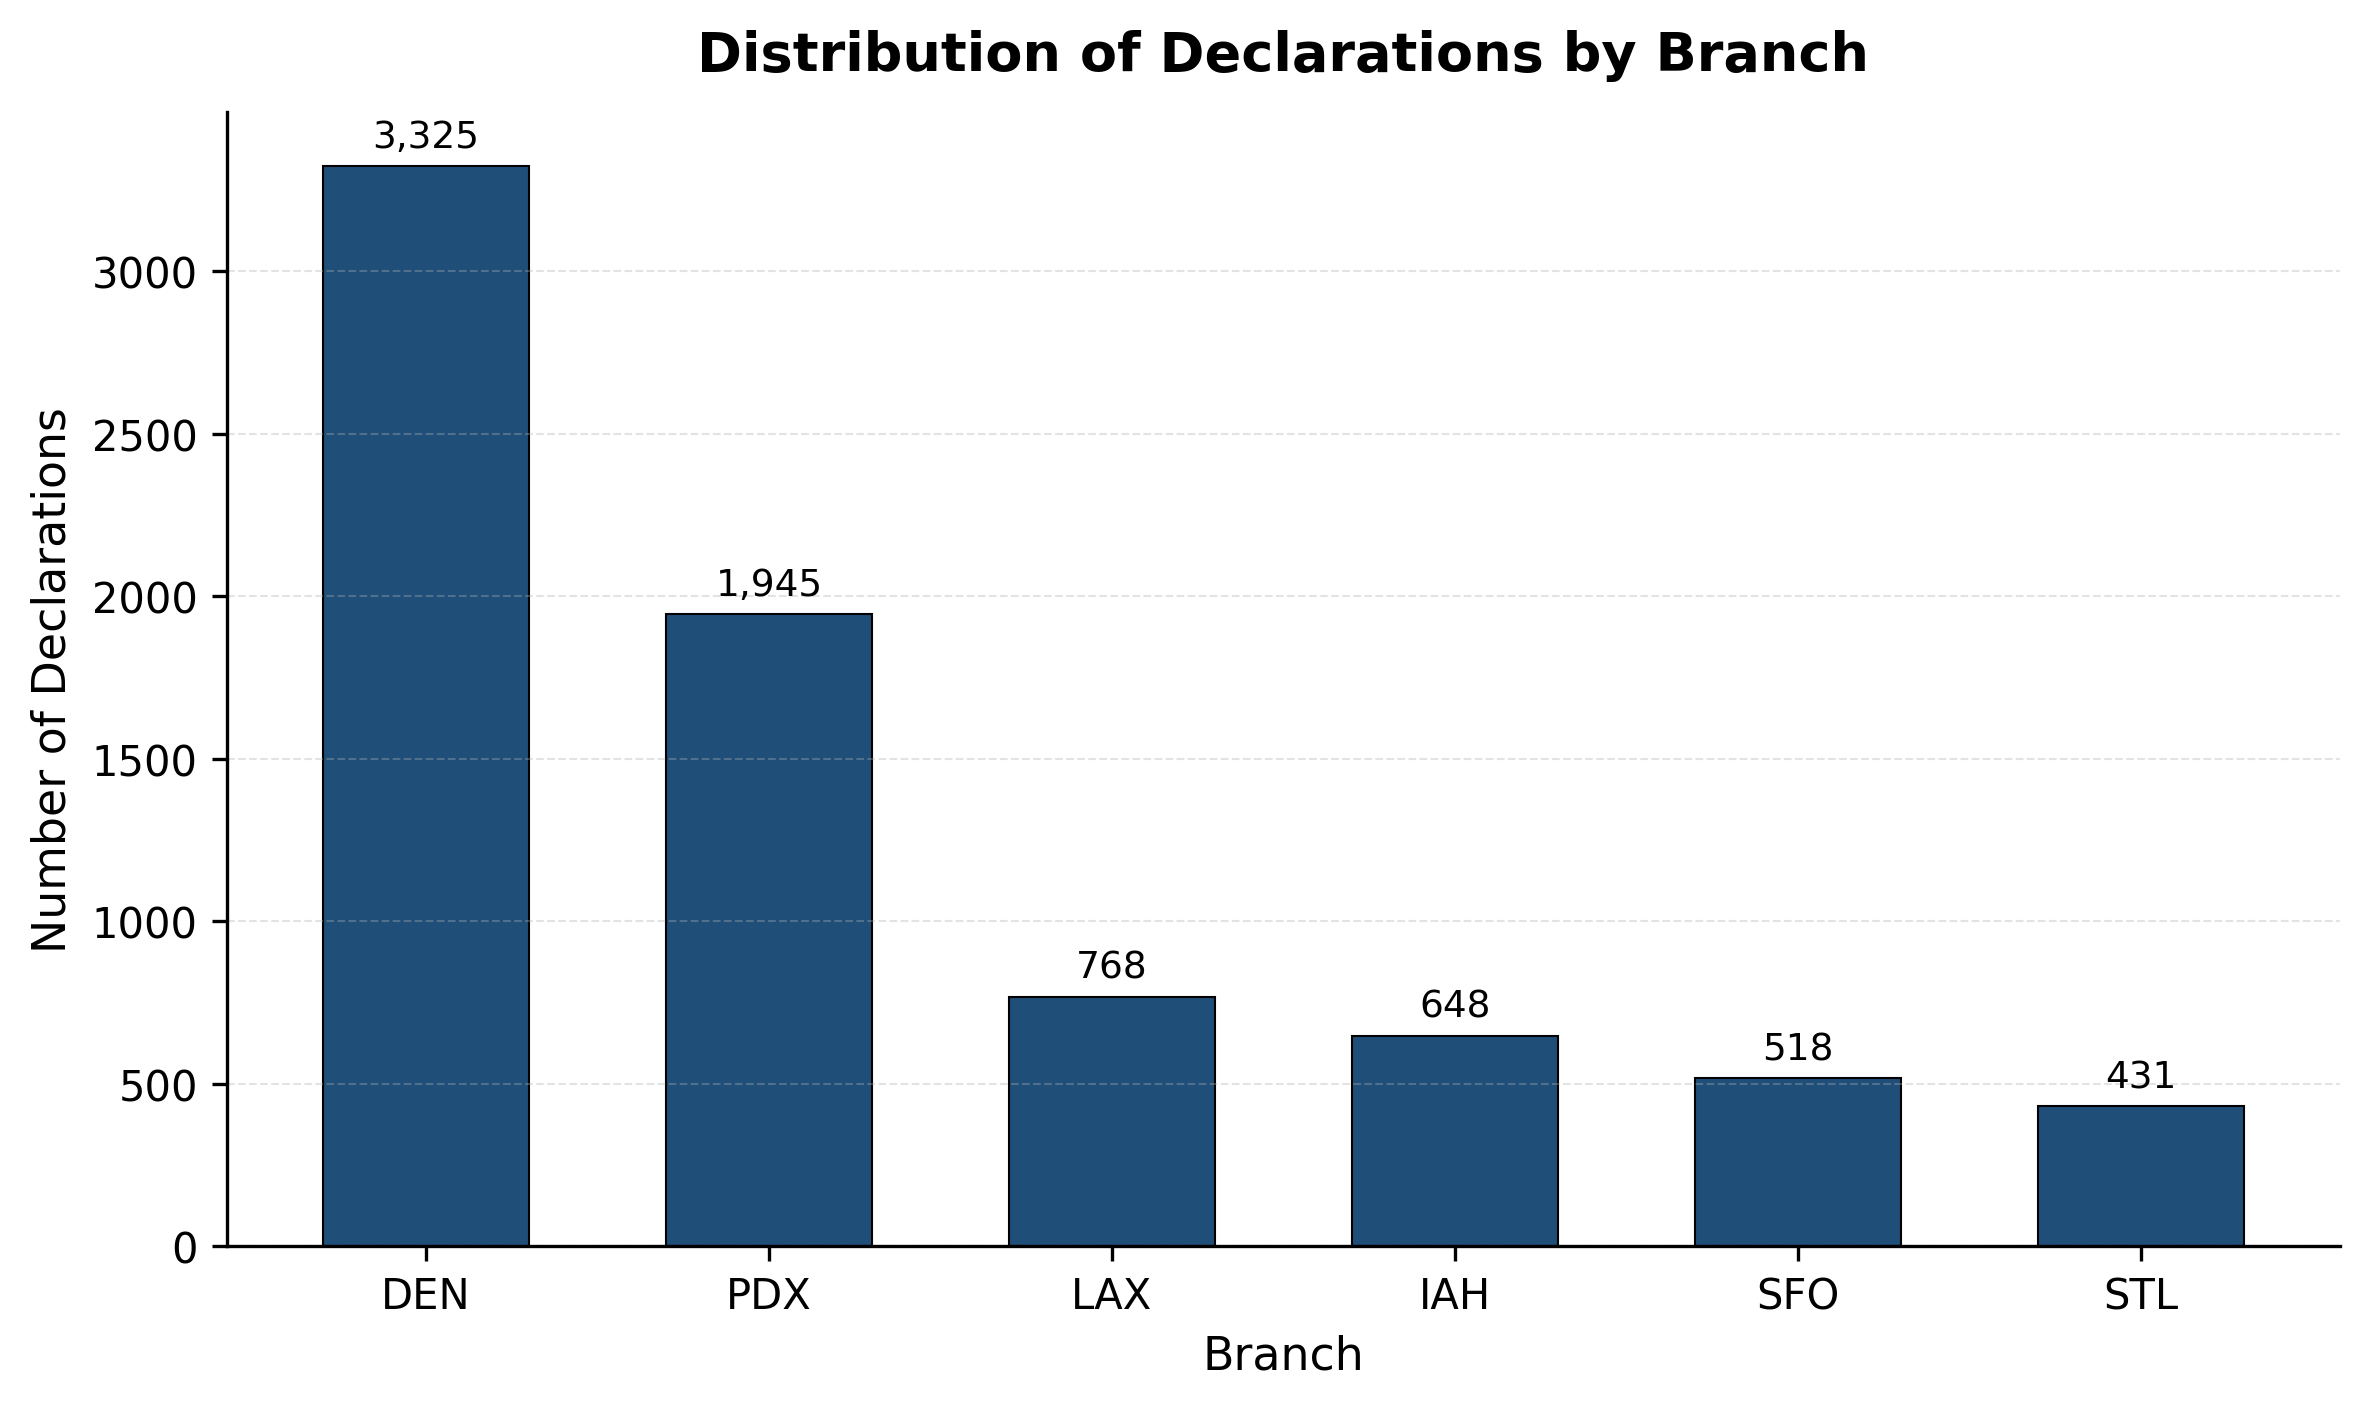

In [54]:
import matplotlib.pyplot as plt

branch_counts = (
    df["Branch"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.8), dpi=300)

bars = ax.bar(
    branch_counts.index,
    branch_counts.values,
    color="#1F4E79",
    edgecolor="black",
    linewidth=0.5,
    width=0.6
)

ax.set_title(
    "Distribution of Declarations by Branch",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Branch", fontsize=11)
ax.set_ylabel("Number of Declarations", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.35)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(branch_counts) * 0.01,
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

This chart shows the distribution of declarations across branches. The Denver branch dominates operations, handling a significantly higher volume than all other locations. Portland represents a secondary hub, while the remaining branches contribute at a much smaller scale. This concentration may introduce operational risk and makes overall performance highly dependent on a single branch.

Branch Reference:

DEN – Denver  
PDX – Portland  
LAX – Los Angeles  
IAH – Houston  
SFO – San Francisco  
STL – St. Louis  

# 2. PROFITABILITY ANALYSIS

The second stage of the analysis examines financial performance. Since profitability is the primary target variable in this study, understanding how profit varies across shipments, branches, and operational conditions is essential for identifying factors that may contribute to successful shipment outcomes.

## 2.1 Monthly Profit Trend

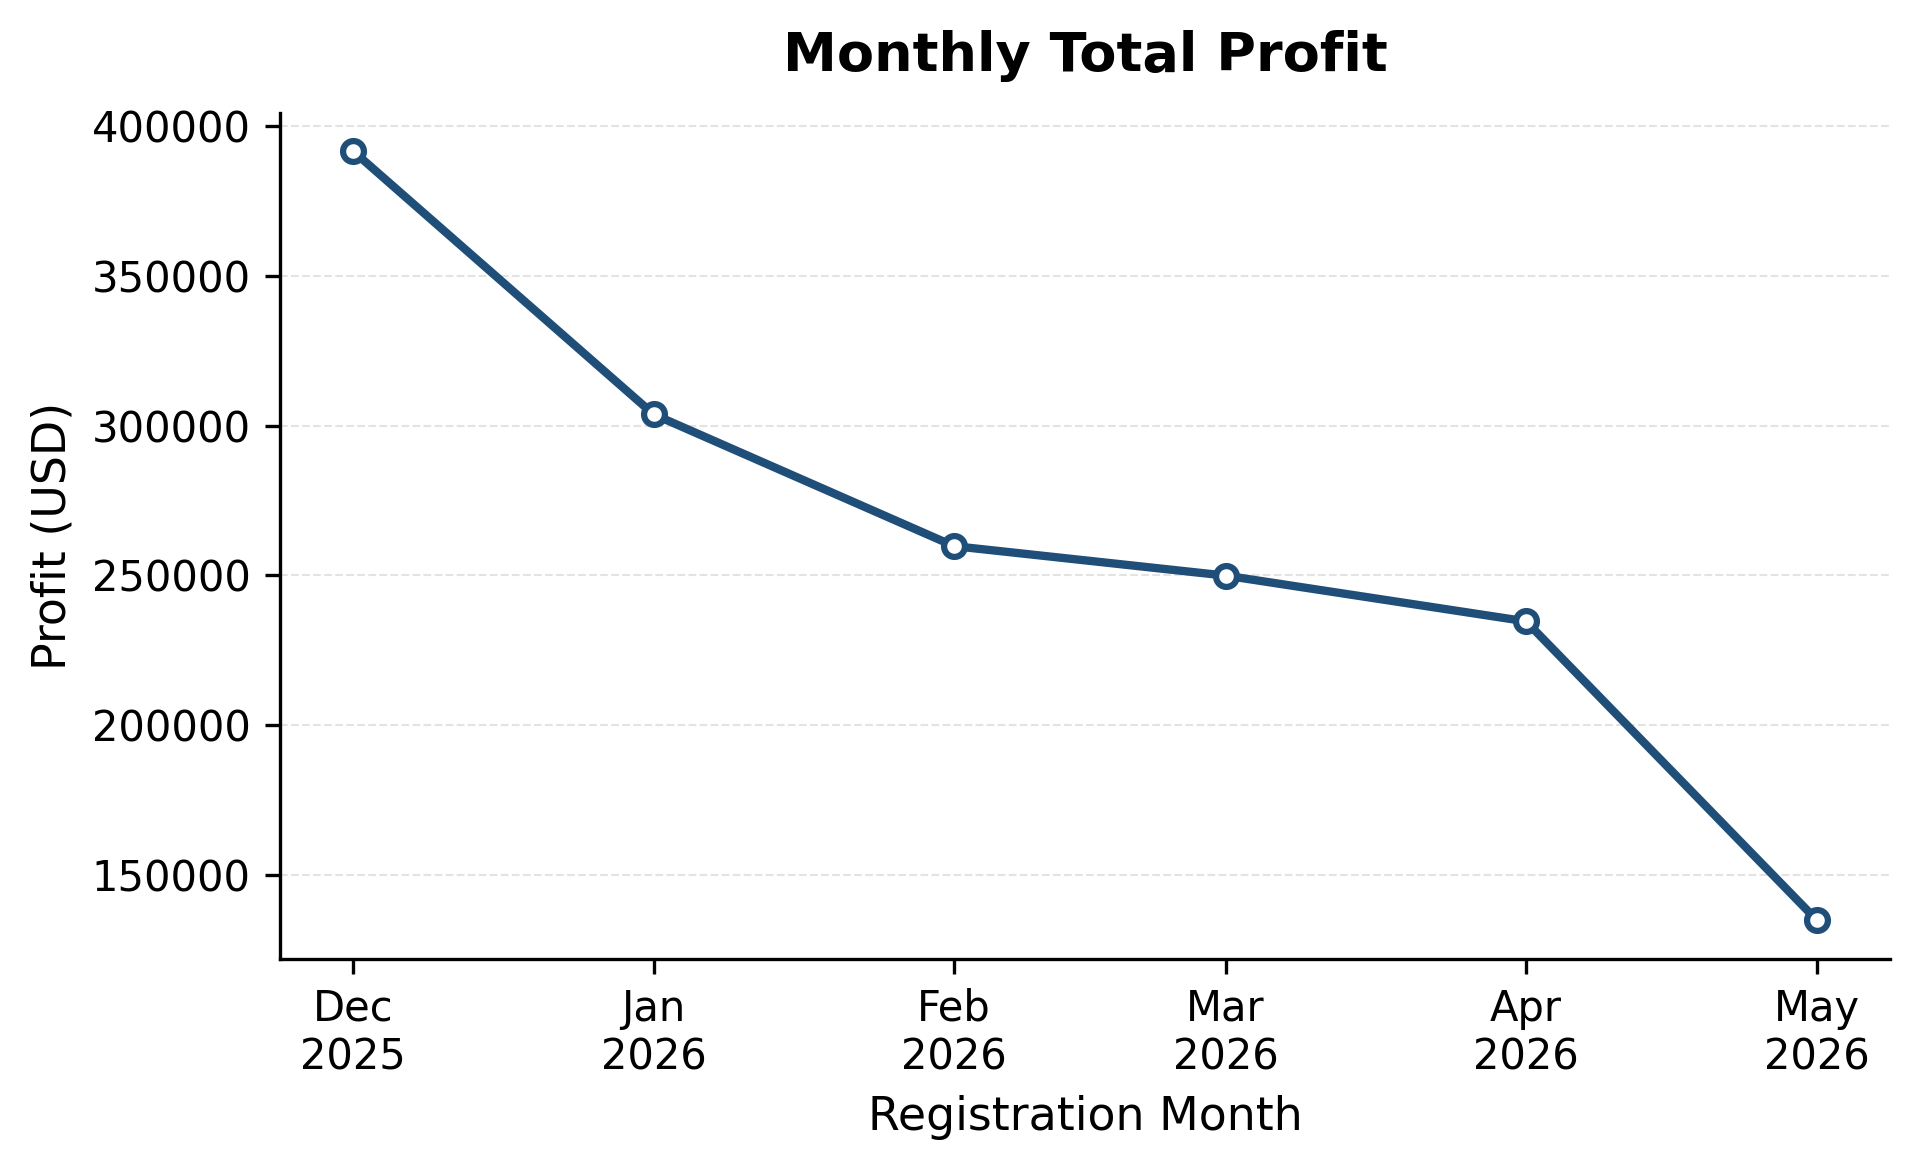

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

monthly_profit = df.groupby("reg_month")["Job Profit"].sum()

monthly_profit.index = monthly_profit.index.to_timestamp()

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

ax.plot(
    monthly_profit.index,
    monthly_profit.values,
    color="#1F4E79",
    linewidth=2,
    marker="o",
    markersize=5,
    markerfacecolor="white",
    markeredgewidth=1.5
)

ax.set_title(
    "Monthly Total Profit",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Registration Month", fontsize=11)
ax.set_ylabel("Profit (USD)", fontsize=11)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The monthly profit trend shows a clear decline after December, which represents the peak in profitability. This pattern closely follows the decrease in operational activity, indicating that profit is strongly linked to shipment volume. However, the sharp drop observed in later months also suggests that operational efficiency and cost factors may be affecting overall profitability.

## 2.2 Profit by Branch

C:\Users\thati\AppData\Local\Temp\ipykernel_22244\68144768.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Branch")["Job Profit"]


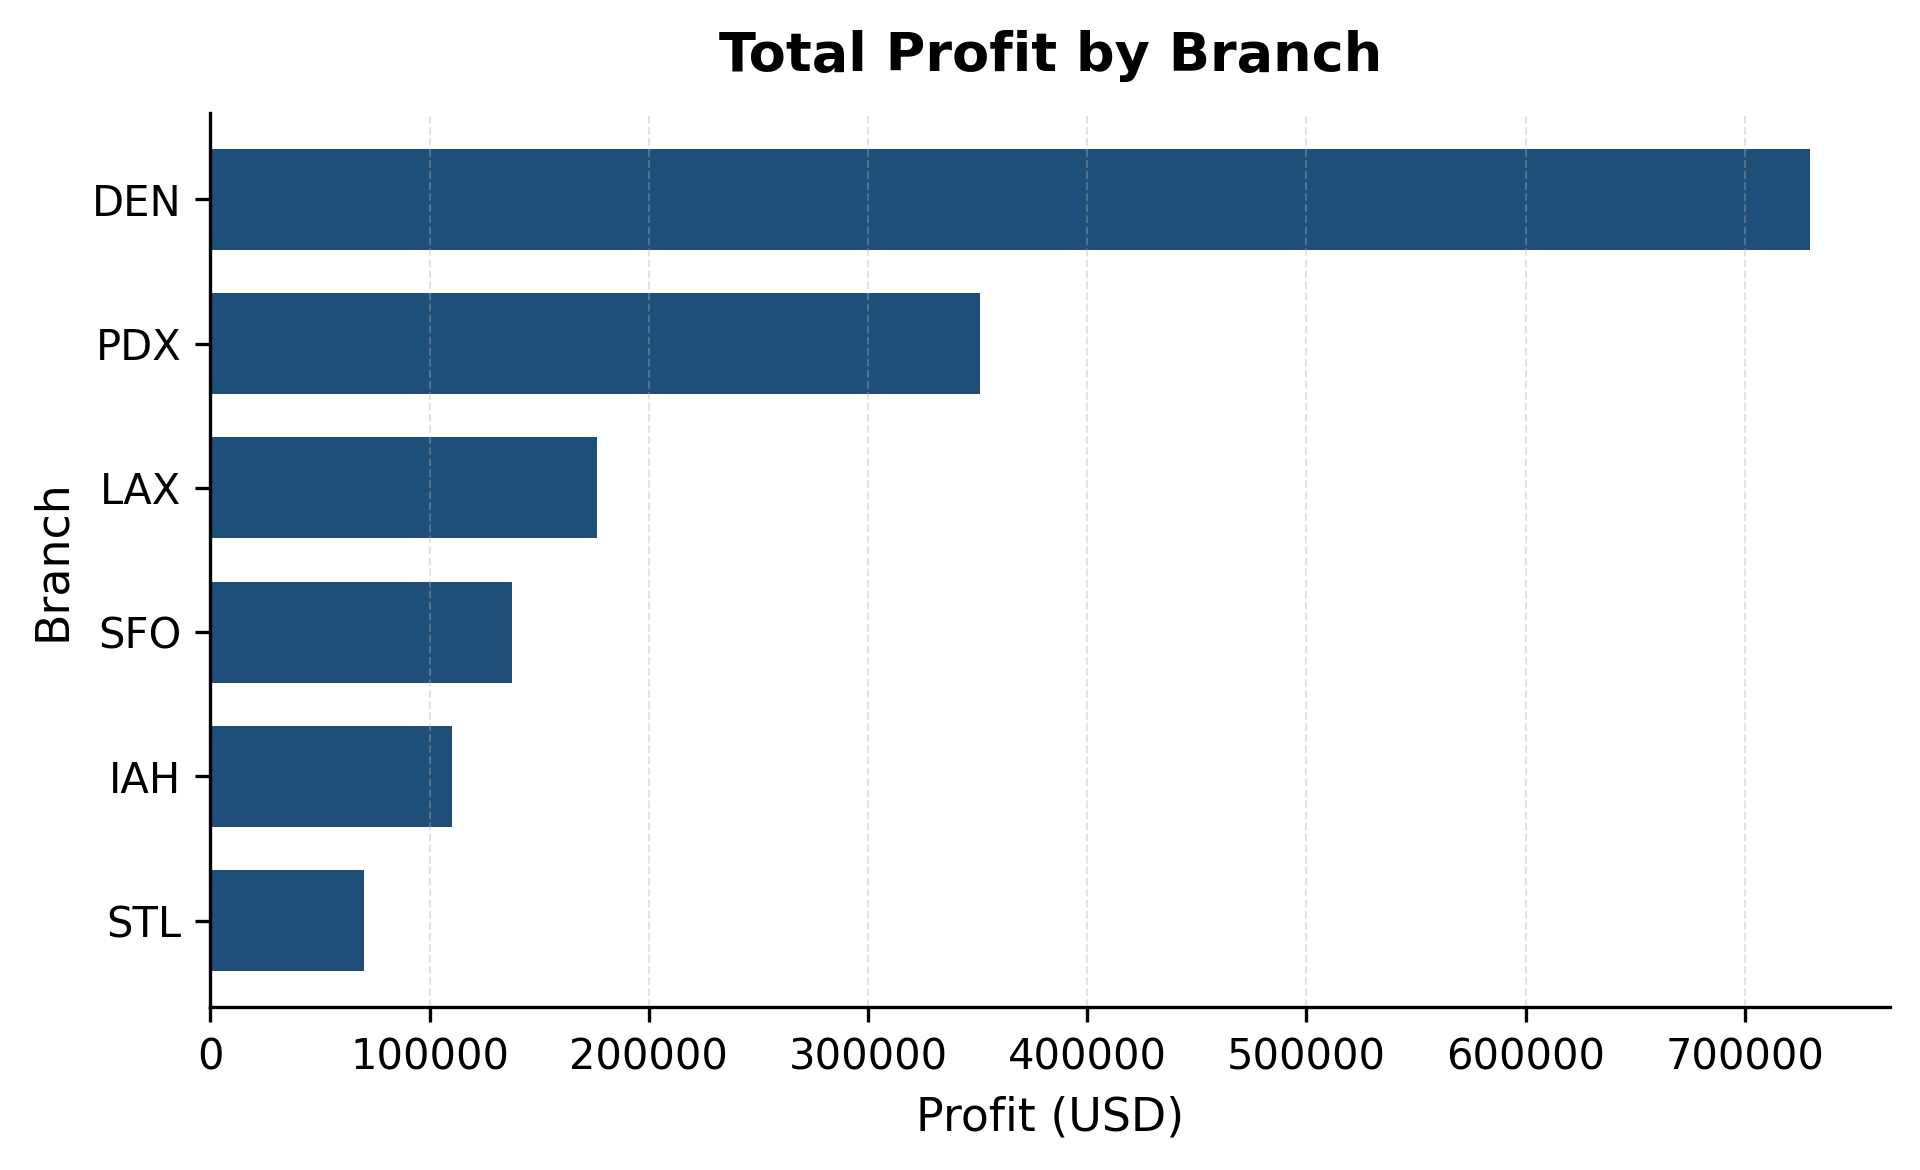

In [56]:
import matplotlib.pyplot as plt

branch_profit = (
    df.groupby("Branch")["Job Profit"]
      .sum()
      .sort_values()
)

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

branch_profit.plot(
    kind="barh",
    ax=ax,
    color="#1F4E79",
    width=0.7
)

ax.set_title(
    "Total Profit by Branch",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Profit (USD)", fontsize=11)
ax.set_ylabel("Branch", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The profit distribution by branch shows that Denver generates the highest profit by a large margin, followed by Portland. This aligns with the earlier observation that Denver also handles the highest operational volume, indicating a strong relationship between activity and profitability. However, this concentration suggests a dependency on a single branch, which may introduce operational and financial risk.

## 2.3 Revenue vs Profit

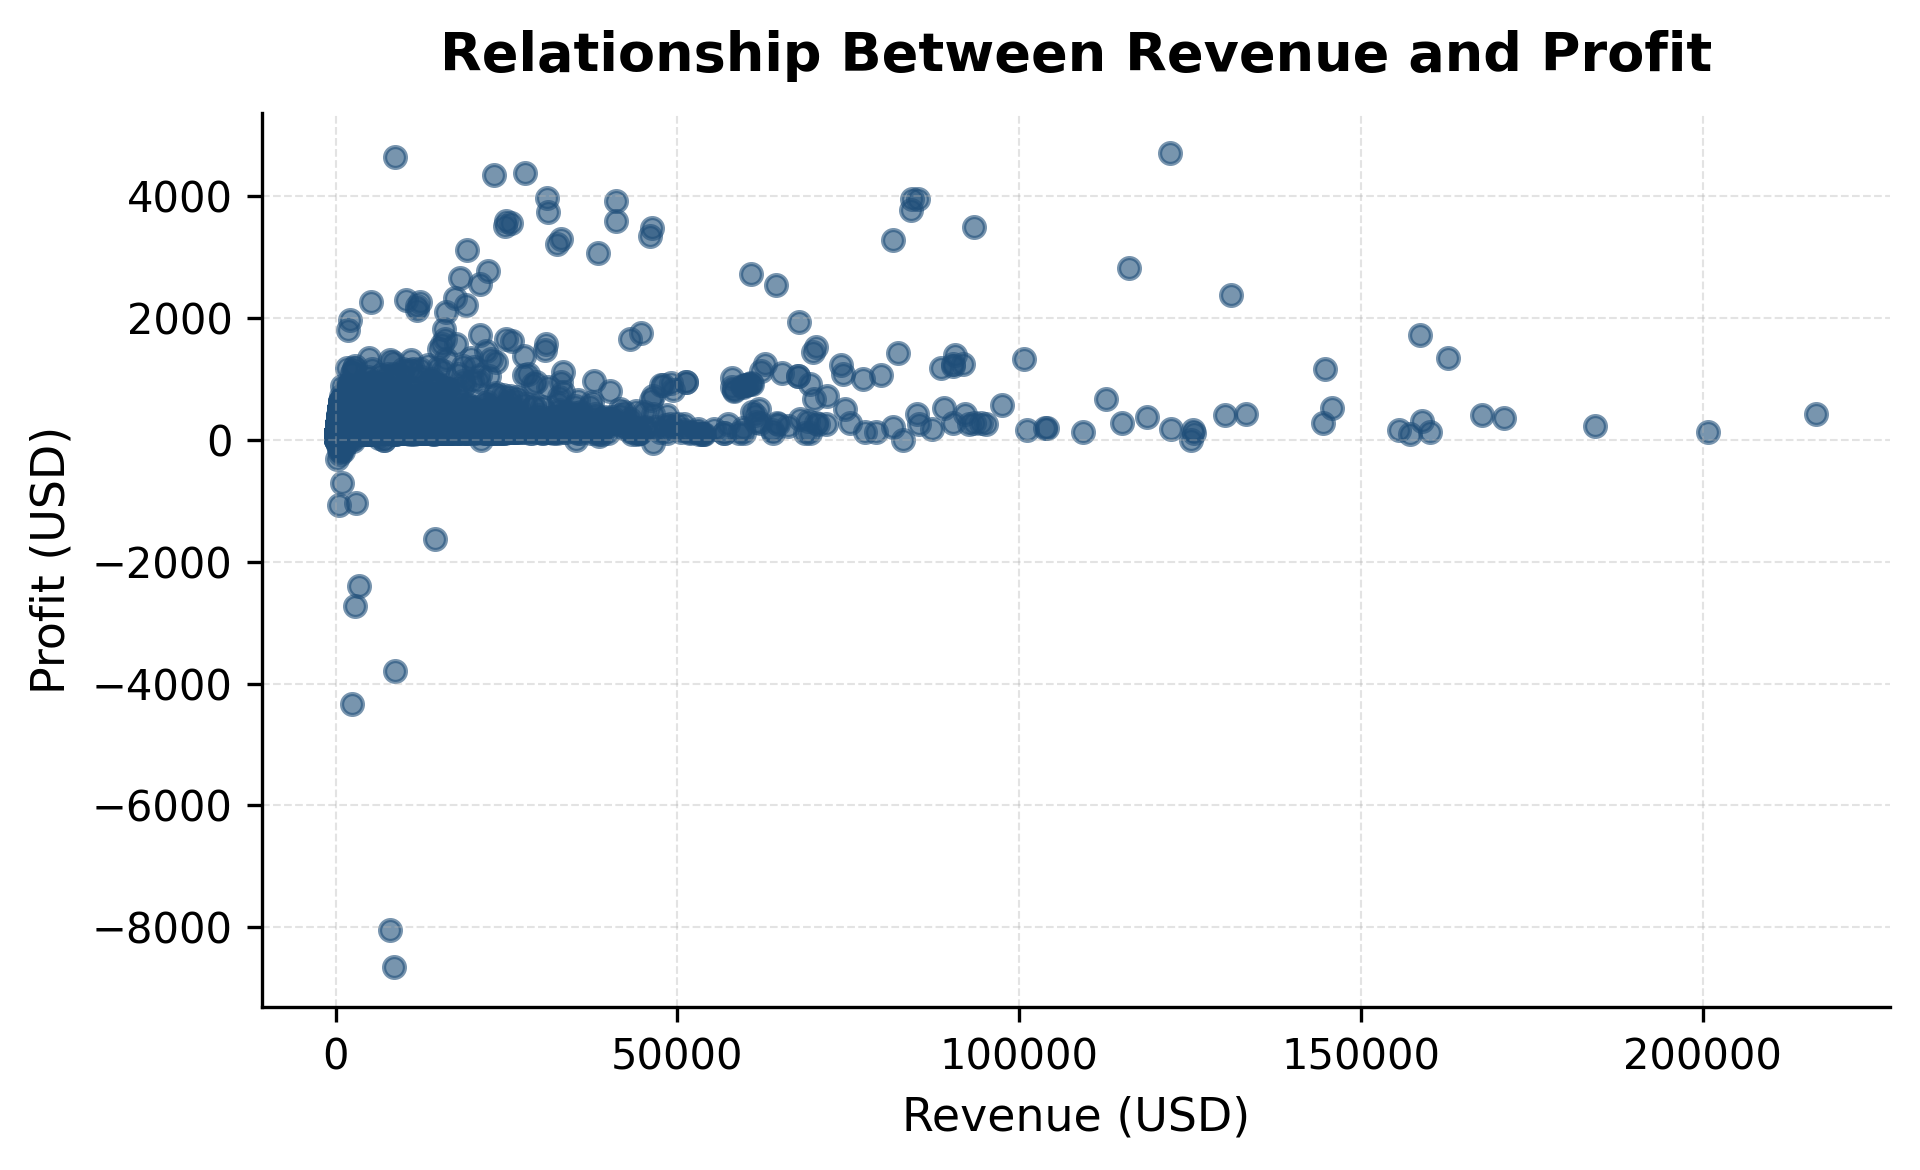

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

ax.scatter(
    df["Revenue"],
    df["Job Profit"],
    color="#1F4E79",
    alpha=0.6,
    s=25
)

ax.set_title(
    "Relationship Between Revenue and Profit",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Revenue (USD)", fontsize=11)
ax.set_ylabel("Profit (USD)", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The scatter plot shows the relationship between revenue and profit. While there is a general positive trend, the relationship is relatively weak. Notably, several cases exhibit high revenue but low or even negative profit, indicating that revenue alone does not guarantee profitability. This suggests that cost management and operational efficiency play a critical role in financial performance.

## 2.4 Profit by Transport Type

C:\Users\thati\AppData\Local\Temp\ipykernel_22244\3634424721.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Transport Type")["Job Profit"]


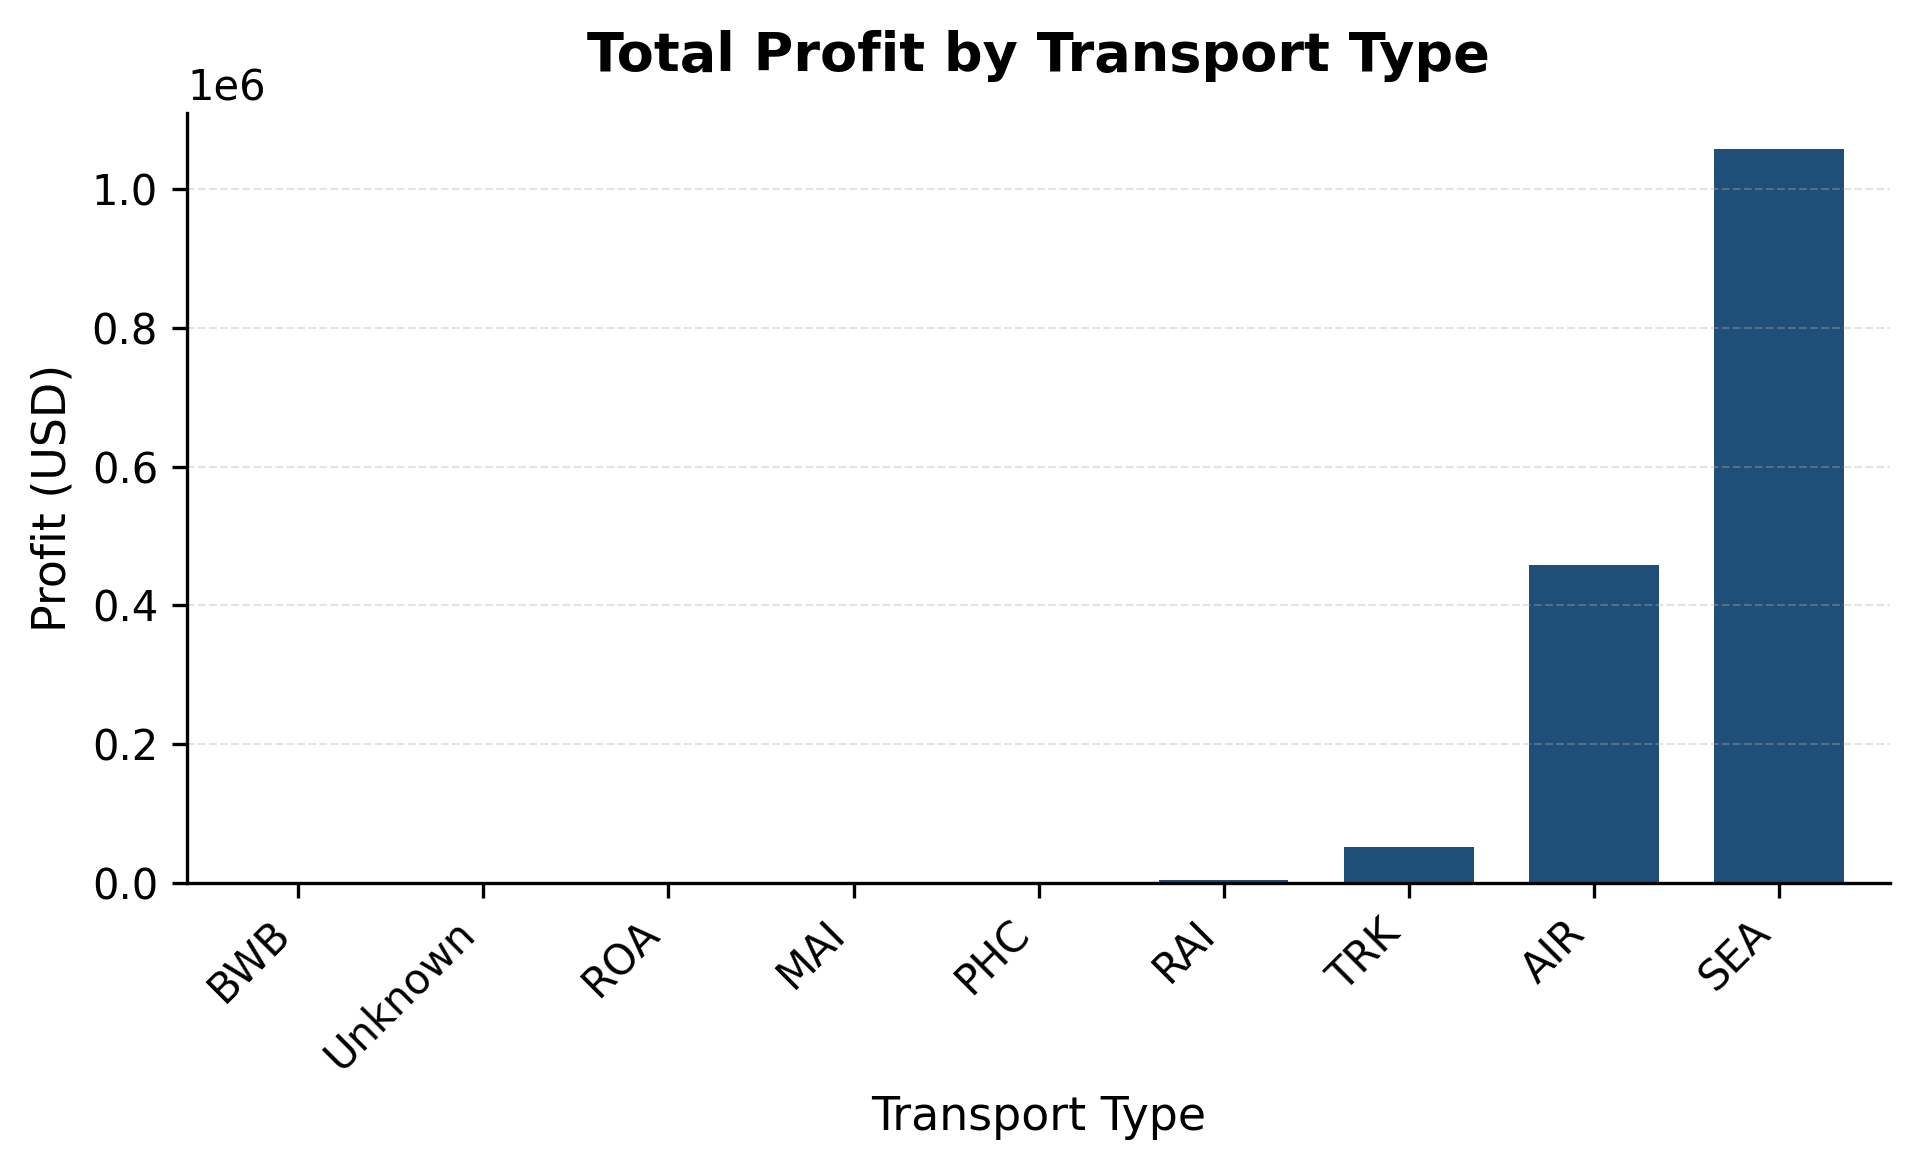

In [58]:
import matplotlib.pyplot as plt

transport_profit = (
    df.groupby("Transport Type")["Job Profit"]
      .sum()
      .sort_values()
)

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

transport_profit.plot(
    kind="bar",
    ax=ax,
    color="#1F4E79",
    width=0.7
)

ax.set_title(
    "Total Profit by Transport Type",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Transport Type", fontsize=11)
ax.set_ylabel("Profit (USD)", fontsize=11)

ax.tick_params(axis="both", labelsize=10)
plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [59]:
df["Job Profit"].describe()

count    7635.000000
mean      206.210716
std       326.907884
min     -8642.950000
25%       107.050000
50%       150.000000
75%       243.845000
max      4699.270000
Name: Job Profit, dtype: float64

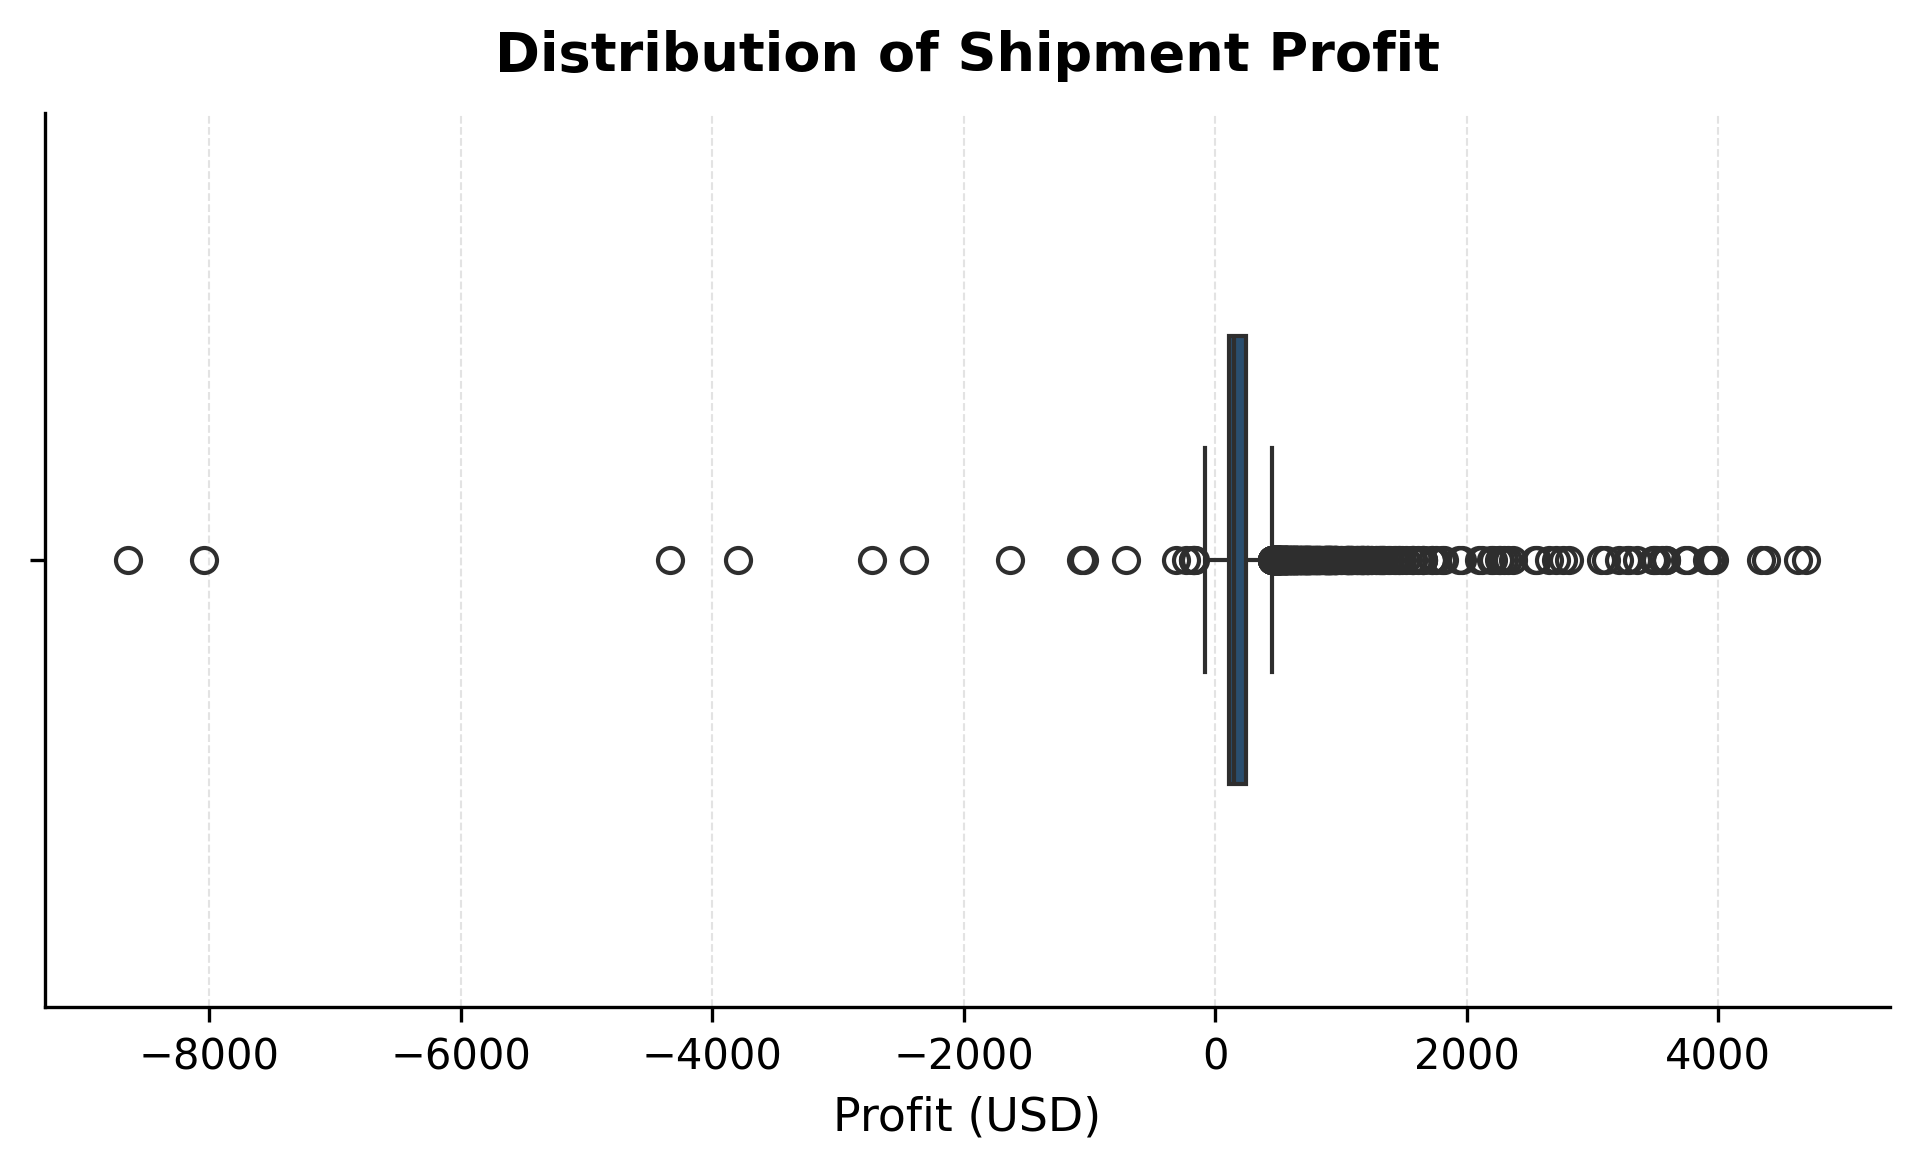

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

sns.boxplot(
    x=df["Job Profit"],
    ax=ax,
    color="#1F4E79",
    width=0.5
)

ax.set_title(
    "Distribution of Shipment Profit",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Profit (USD)", fontsize=11)
ax.set_ylabel("")

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# 3. DELAY ANALYSIS

The final exploratory analysis focuses on operational efficiency. Delays and processing times are important indicators of logistics performance and may directly affect customer satisfaction and shipment profitability. Understanding these operational patterns provides valuable insight into factors that could influence predictive model performance.


## 3.1 Delay Distribution

In [61]:
df["Delay"] = (df["Arrival ATA"] - df["Dest. ETA"]).dt.days

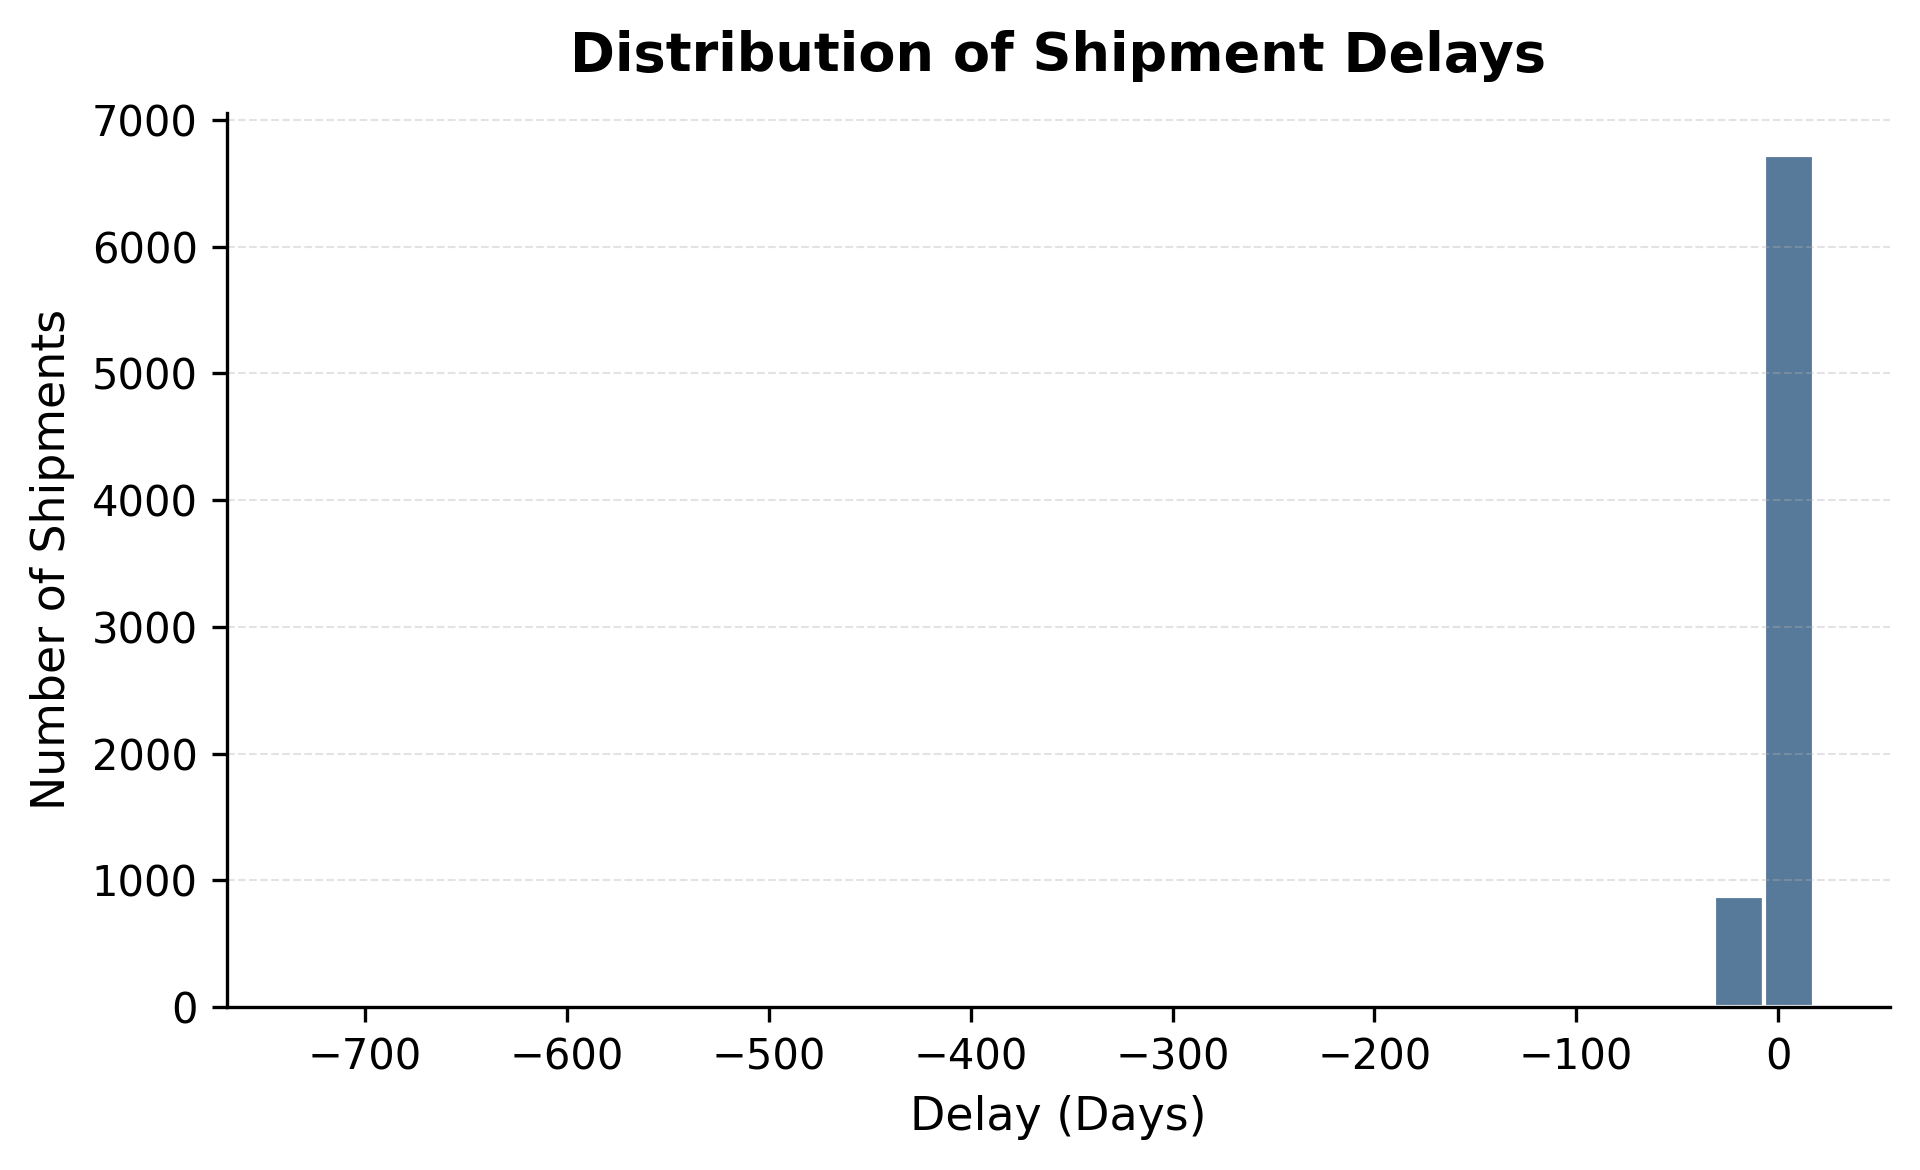

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

sns.histplot(
    df["Delay"],
    bins=30,
    color="#1F4E79",
    edgecolor="white",
    ax=ax
)

ax.set_title(
    "Distribution of Shipment Delays",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Delay (Days)", fontsize=11)
ax.set_ylabel("Number of Shipments", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The delay distribution shows that most shipments are concentrated around zero, indicating that operations are generally on time. However, the presence of extreme negative outliers suggests potential data inconsistencies or anomalies. These values may need to be addressed before modeling to ensure accurate predictions.

## 3.2 Delay by Transport Type

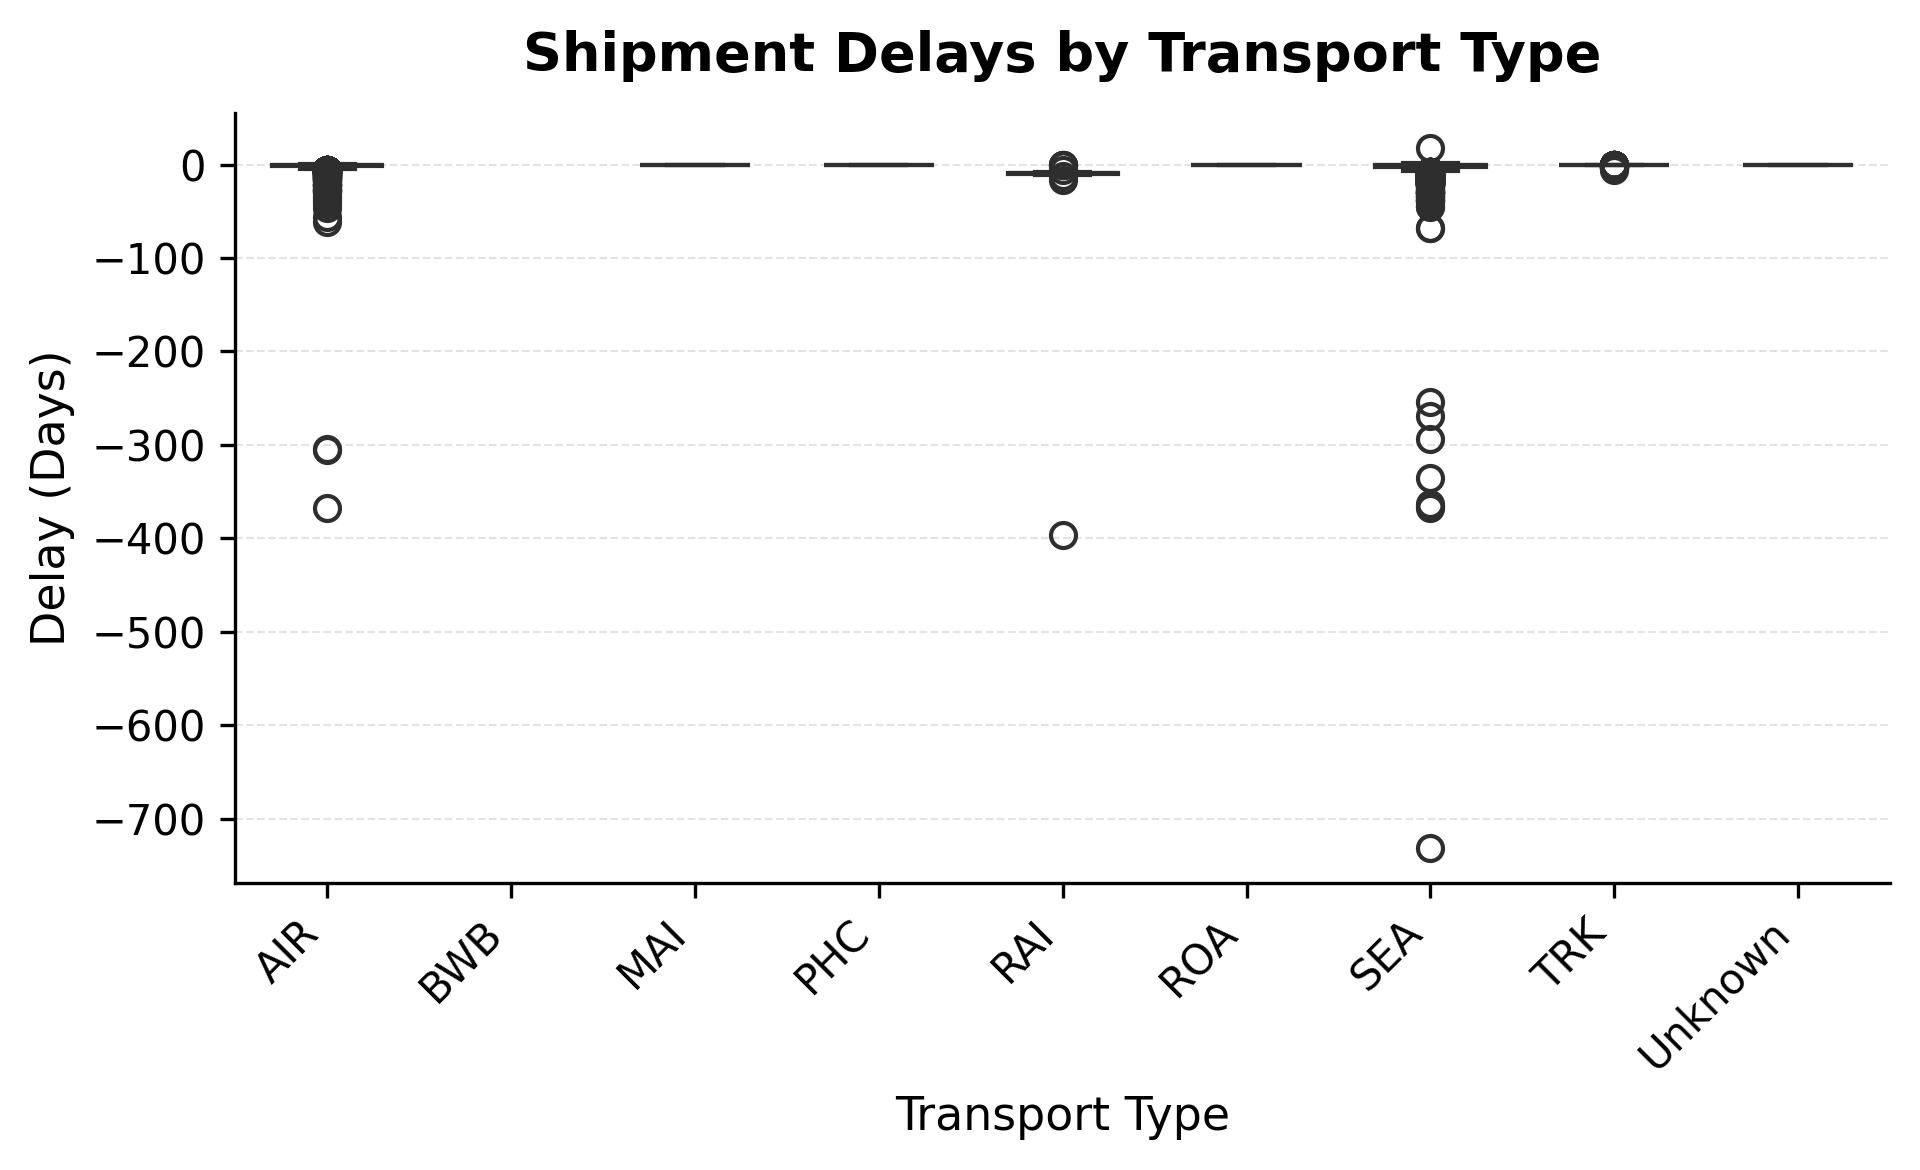

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

sns.boxplot(
    x="Transport Type",
    y="Delay",
    data=df,
    color="#1F4E79",
    width=0.6,
    ax=ax
)

ax.set_title(
    "Shipment Delays by Transport Type",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Transport Type", fontsize=11)
ax.set_ylabel("Delay (Days)", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

plt.xticks(rotation=45, ha="right")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The analysis of delay by transport type shows that most shipments across all modes are concentrated around zero delay. However, sea transport exhibits significantly higher variability and extreme outliers, indicating greater operational risk and inconsistency. In contrast, air transport appears more stable. These differences highlight the importance of transport type as a key factor in delay prediction.

## 3.3 Delay vs Profit

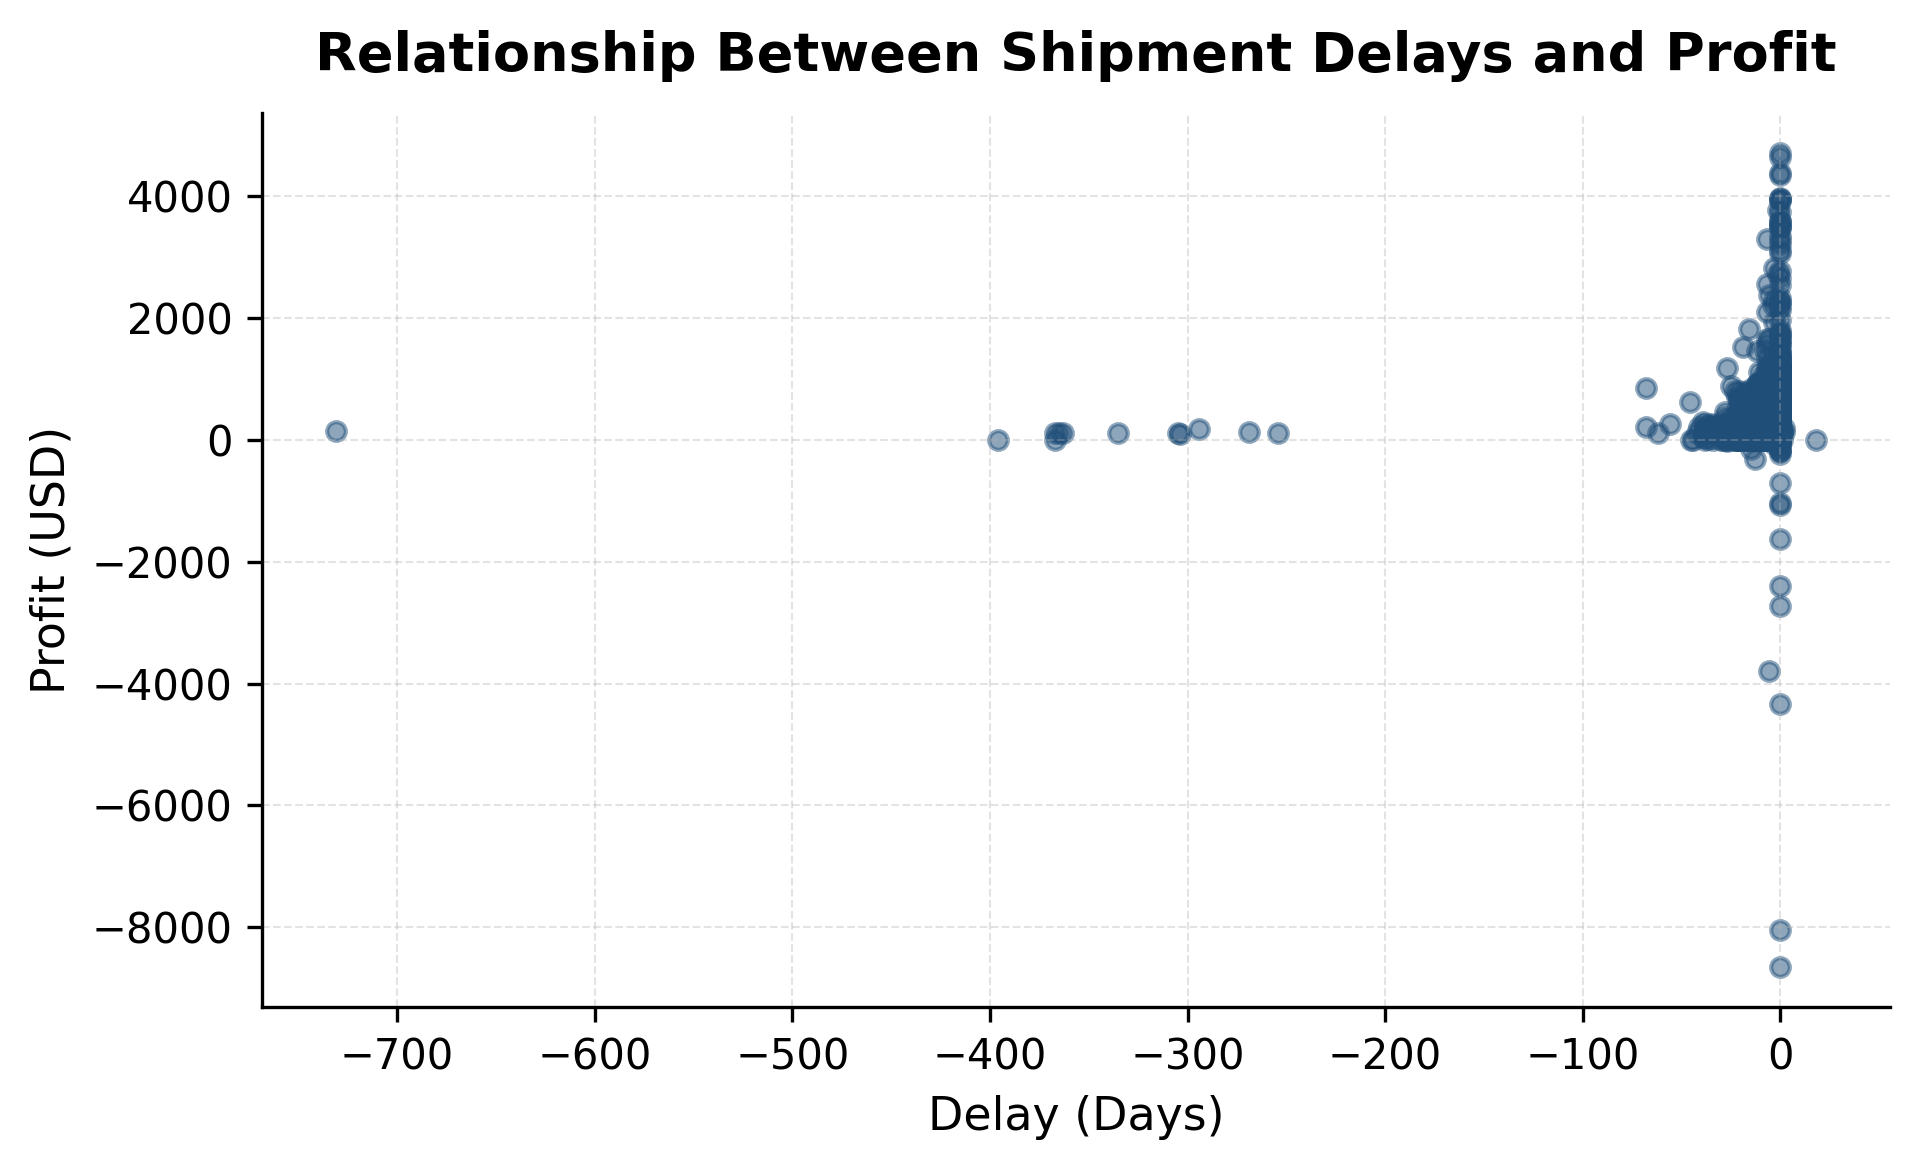

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

ax.scatter(
    df["Delay"],
    df["Job Profit"],
    color="#1F4E79",
    alpha=0.5,
    s=20
)

ax.set_title(
    "Relationship Between Shipment Delays and Profit",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Delay (Days)", fontsize=11)
ax.set_ylabel("Profit (USD)", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


The relationship between delay and profit shows no strong linear pattern. While most shipments are near zero delay, profitability varies widely, including both high profits and losses. This indicates that delay alone does not explain financial performance. The variability suggests that other factors, such as cost and operational efficiency, play a critical role. Additionally, the presence of extreme outliers highlights the need for further data treatment before modeling.

## Shipments with Delay

In [65]:
total_shipments = len(df)

delayed_shipments = (df["Delay"] > 0).sum()

print("Total shipments:", total_shipments)
print("Shipments with delay:", delayed_shipments)

Total shipments: 7635
Shipments with delay: 6


Only 0.08% of shipments experienced delays, indicating a highly imbalanced distribution. This limits the predictive value of delay modeling, as most observations correspond to on-time deliveries.

# Heatmap

In [66]:
numeric_cols = [
    "Invoice Headers",
    "Invoice Lines",
    "Weight",
    "Volume",
    "Packs",
    "Revenue",
    "Total Income",
    "Cost",
    "Total Expense",
    "Job Profit",
    "Container Count",
    "TEU"
]

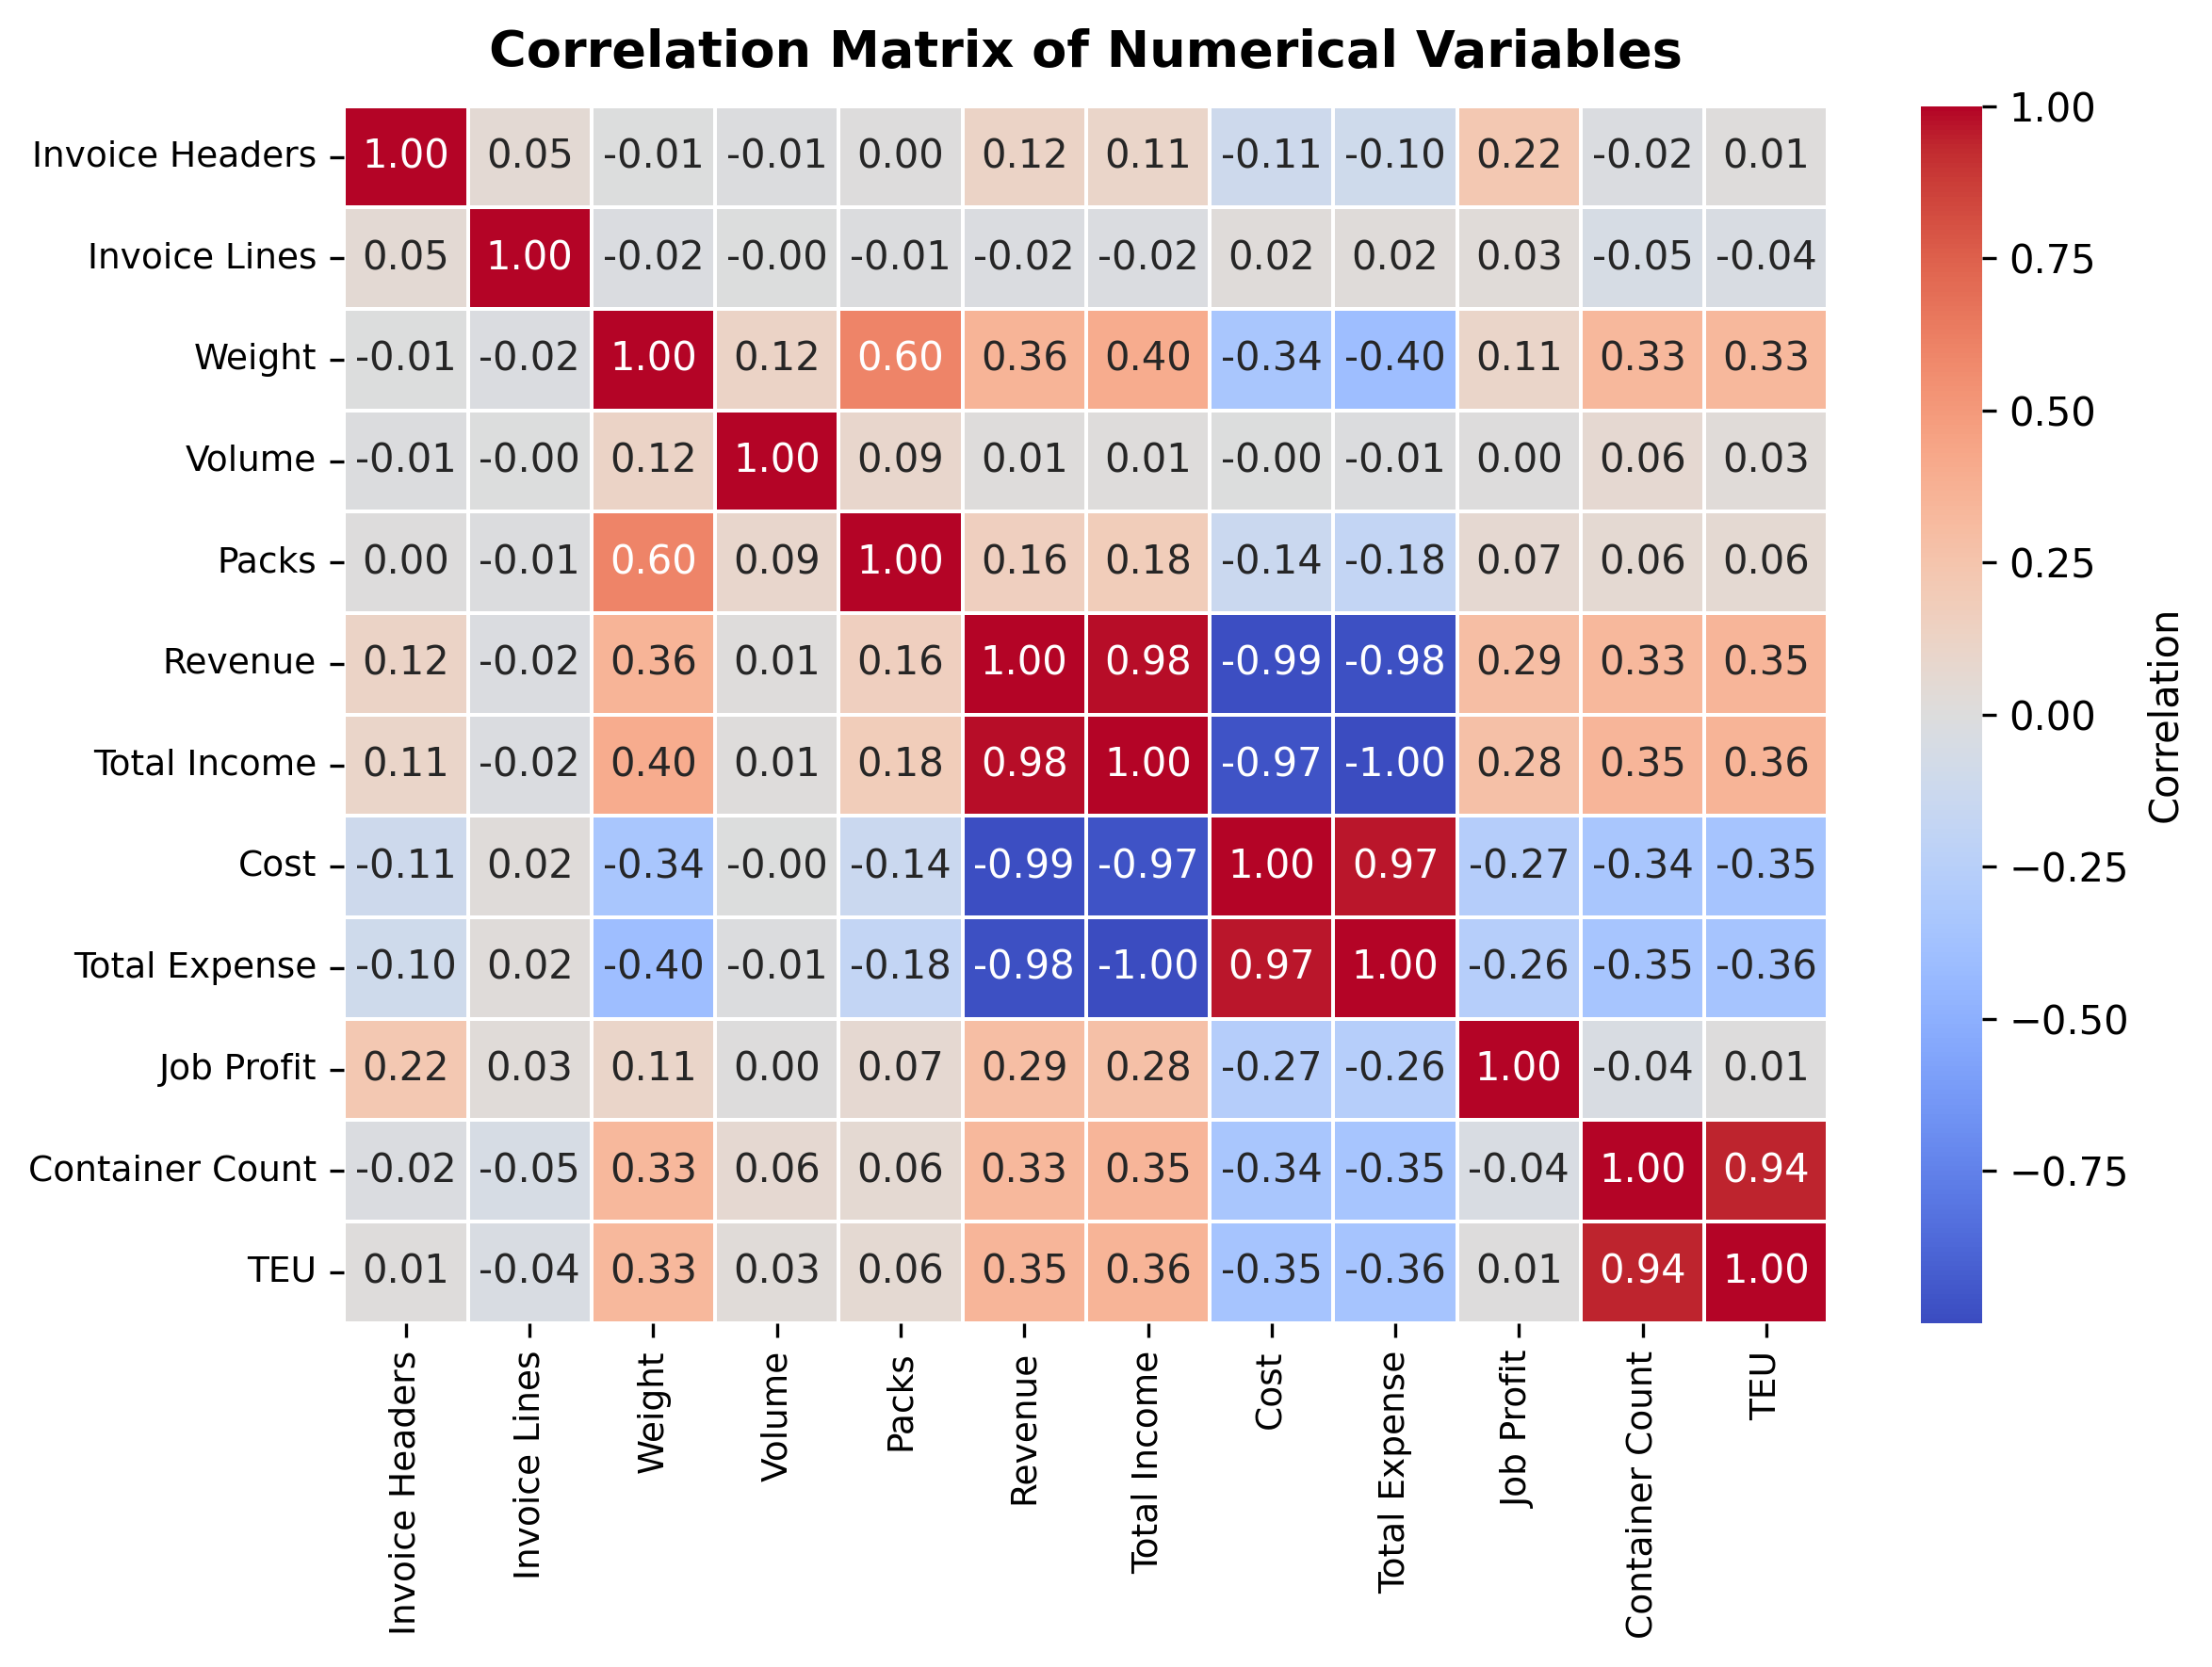

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
    ax=ax
)

ax.set_title(
    "Correlation Matrix of Numerical Variables",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.show()


## Correlation Analysis

The correlation heatmap reveals strong relationships among financial variables, particularly between revenue and total income (≈0.98), as well as strong inverse correlations with cost and total expense (≈ -0.97 to -0.99). 

- This indicates a high level of redundancy among financial variables, as they capture closely related aspects of the same financial structure.

In contrast, job profit shows only moderate correlations with these variables (≈0.25–0.30), suggesting that profitability is not directly determined by a single financial metric. 

- This highlights that high revenue does not necessarily result in high profit, reinforcing the importance of efficiency rather than scale.

Additionally, shipment size variables such as weight, packs, and container count show moderate correlations with revenue (≈0.30–0.60), indicating that larger shipments tend to generate higher revenue, but not proportionally higher profitability.

- This suggests that shipment size alone is not a reliable indicator of profit.

### Key Insight

Profitability is not strongly correlated with any single variable, indicating that it is driven by a combination of factors rather than isolated inputs. This supports the use of machine learning models capable of capturing complex, non-linear relationships.

# Feature Engineering   

Following the exploratory analysis, feature engineering was performed to create additional variables that could improve predictive performance. The objective was to transform raw operational data into more informative features capable of capturing seasonality, shipment characteristics, and process efficiency. These engineered variables were later used as inputs for the machine learning models.

## Temporal Features

In [68]:
df["month"] = df["Dec. Registered"].dt.month

In [69]:
df["weekday"] = df["Dec. Registered"].dt.weekday

In [70]:
df["quarter"] = df["month"].apply(lambda x: (x - 1) // 3 + 1)

In [71]:
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

In [72]:
df[["Dec. Registered", "month"]].head(5)

,Dec. Registered,month
0,2025-12-01 15:13:00,12
1,2025-12-01 15:15:00,12
3,2025-12-01 15:18:00,12
4,2025-12-01 16:01:00,12
5,2025-12-01 16:07:00,12


Temporal features were created from the shipment registration date to capture seasonal and operational patterns. Variables such as month, weekday, quarter, and weekend indicators were used to reflect time-based variations that may influence shipment activity and profitability.

## Logistical Time Features

## Transit Time

In [73]:
df["transit_time"] = (df["Arrival ATA"] - df["Origin ETD"]).dt.days

In [74]:
df[["Origin ETD", "Arrival ATA", "transit_time"]].head(5)

,Origin ETD,Arrival ATA,transit_time
0,2025-11-27,2025-11-27,0
1,2025-11-26,2025-11-29,3
3,2025-10-04,2025-12-01,58
4,2025-11-19,2025-12-02,13
5,2025-10-15,2025-11-30,46


Transit time was calculated as the number of days between the estimated departure date and the actual arrival date, representing the total duration of the shipment process. This feature captures transportation efficiency and is expected to influence profitability, as longer transit times may increase operational costs and reduce margins.

## Handling Time


In [75]:
df["handling_time"] = (df["Load ATD"] - df["Origin ETD"]).dt.days

In [76]:
df[["Origin ETD", "Load ATD", "handling_time"]].head(5)

,Origin ETD,Load ATD,handling_time
0,2025-11-27,2025-11-27,0
1,2025-11-26,2025-11-26,0
3,2025-10-04,2025-10-04,0
4,2025-11-19,2025-11-19,0
5,2025-10-15,2025-10-15,0


Handling time was defined as the number of days between the estimated departure date and the actual loading date. This feature captures internal operational efficiency, including preparation, documentation, and loading processes. Higher handling times indicate potential inefficiencies in shipment processing, which may increase operational costs and negatively impact profitability.

In [77]:
df["handling_time"] = df["handling_time"].clip(lower=0)

In [78]:
df["handling_time"].value_counts()

handling_time
0       7072
1        186
2        100
3         55
4         28
5         27
7         22
8         20
13        12
11         9
10         9
6          9
9          7
16         7
365        6
14         6
20         6
31         5
27         4
28         4
18         4
29         3
19         3
12         2
17         2
30         2
15         2
23         2
41         1
56         1
21         1
367        1
48         1
1096       1
303        1
37         1
2192       1
24         1
366        1
40         1
22         1
39         1
33         1
379        1
44         1
49         1
47         1
86         1
89         1
Name: count, dtype: int64

The handling time feature exhibited low variability, with more than 90% of the observations equal to zero, indicating that most shipments were processed on the same day. 

## Total Process Time

In [79]:
df["total_process_time"] = (df["Arrival ATA"] - df["Job Opened"]).dt.days

In [80]:
df["total_process_time"] = df["total_process_time"].clip(lower=0)

In [81]:
df[["Job Opened", "Arrival ATA", "total_process_time"]].head(5)

,Job Opened,Arrival ATA,total_process_time
0,2025-12-01 15:13:00,2025-11-27,0
1,2025-12-01 15:15:00,2025-11-29,0
3,2025-12-01 15:18:00,2025-12-01,0
4,2025-12-01 16:01:00,2025-12-02,0
5,2025-12-01 16:07:00,2025-11-30,0


Total process time was calculated as the number of days between job creation and final delivery. This feature captures the complete duration of the shipment lifecycle, including preparation, handling, and transportation stages.

## Financial Features

In [82]:
df["profit_margin"] = df["Job Profit"] / (df["Revenue"] + 1)

In [83]:
df["cost_ratio"] = df["Cost"] / (df["Revenue"] + 1)

In [84]:
df["expense_ratio"] = df["Total Expense"] / (df["Total Income"] + 1)

In [85]:
df[["profit_margin", "cost_ratio", "expense_ratio"]].describe()

,profit_margin,cost_ratio,expense_ratio
count,7635.000000,7635.000000,7635.000000
mean,0.311763,-0.544091,-0.691676
std,0.355879,0.424565,0.413046
min,-2.389150,-3.727088,-4.161983
25%,0.013876,-0.957541,-0.976895
50%,0.152517,-0.626962,-0.851319
75%,0.547398,-0.065894,-0.434501
max,1.002106,0.079122,0.000047


Financial ratio features were engineered to capture operational efficiency and cost structure. These include cost ratio and expense ratio, which represent the proportion of costs and expenses relative to revenue and income.
These features provide a more meaningful representation of profitability drivers compared to absolute monetary values.
The profit margin variable was initially considered but excluded from modeling due to its direct dependency on the target variable, which could introduce data leakage and artificially inflate model performance.

## Shipment Characteristics

In [86]:

df["weight_to_volume"] = df["Weight"] / (df["Volume"] + 1)


In [87]:
df["revenue_per_weight"] = df["Revenue"] / (df["Weight"] + 1)

In [88]:
df["revenue_per_volume"] = df["Revenue"] / (df["Volume"] + 1)

In [89]:
df["containers_efficiency"] = df["Revenue"] / (df["Container Count"] + 1)

Additional features were engineered to capture shipment characteristics and operational efficiency. These include ratios such as weight-to-volume, revenue per weight, revenue per volume, and revenue per container.
These variables provide insight into shipment density, value distribution, and container utilization, which are important factors in determining operational costs and profitability.

After feature engineering, a feature selection process was conducted to identify the variables most relevant to predicting shipment profitability. Reducing the number of input variables helps improve model interpretability, minimize noise, and reduce the risk of overfitting. The selected features were then used as inputs for the predictive models.

## Target Variable

In [90]:
df["Profit_Flag"] = (df["Job Profit"] > 0).astype(int)

In [91]:
df["Profit_Flag"].value_counts()

Profit_Flag
1    6714
0     921
Name: count, dtype: int64

I am going to balance it.

In [92]:
!{sys.executable} -m pip install scikit-learn


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [93]:
from sklearn.ensemble import RandomForestClassifier

In [94]:
RandomForestClassifier(class_weight="balanced")

RandomForestClassifier(class_weight='balanced')

Several financial ratios were engineered, but ultimately excluded from the final model due to their direct relationship with the target variable, which could introduce data leakage.

# Final Dataset

The selected features represented a combination of operational, temporal, and shipment-specific characteristics. This combination reflects the multifaceted nature of freight profitability, where financial outcomes are influenced by several interacting operational factors rather than a single variable.


In [95]:
num_features = [
    "month", "weekday", "quarter", "is_weekend",
    "Weight",
    "Volume",
    "Packs",
    "Container Count",
    "TEU",
    "Invoice Lines",
    "Invoice Headers",
    "transit_time",
    "total_process_time",
    "weight_to_volume"
]



In [96]:

cat_features = [
    "Transport Type",
    "Branch",
    "Origin Port",
    "Final Destination"
]



In [97]:

X = df[num_features + cat_features]
y = df["Profit_Flag"]


In [98]:
X = pd.get_dummies(X, drop_first=True)

## Train/Test Split

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# MODELING

The next stage involved developing predictive models capable of classifying shipment profitability. Multiple machine learning algorithms were evaluated to compare their ability to capture relationships between shipment characteristics and financial outcomes. Using different modeling approaches provided a broader assessment of predictive performance and model suitability.


## Random Forest

Random Forest was selected because of its ability to capture nonlinear relationships and interactions between variables. In logistics operations, profitability often depends on combinations of shipment characteristics rather than isolated factors, making tree-based methods particularly suitable for this problem

In [100]:

model = RandomForestClassifier(class_weight="balanced")
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced')

In [101]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

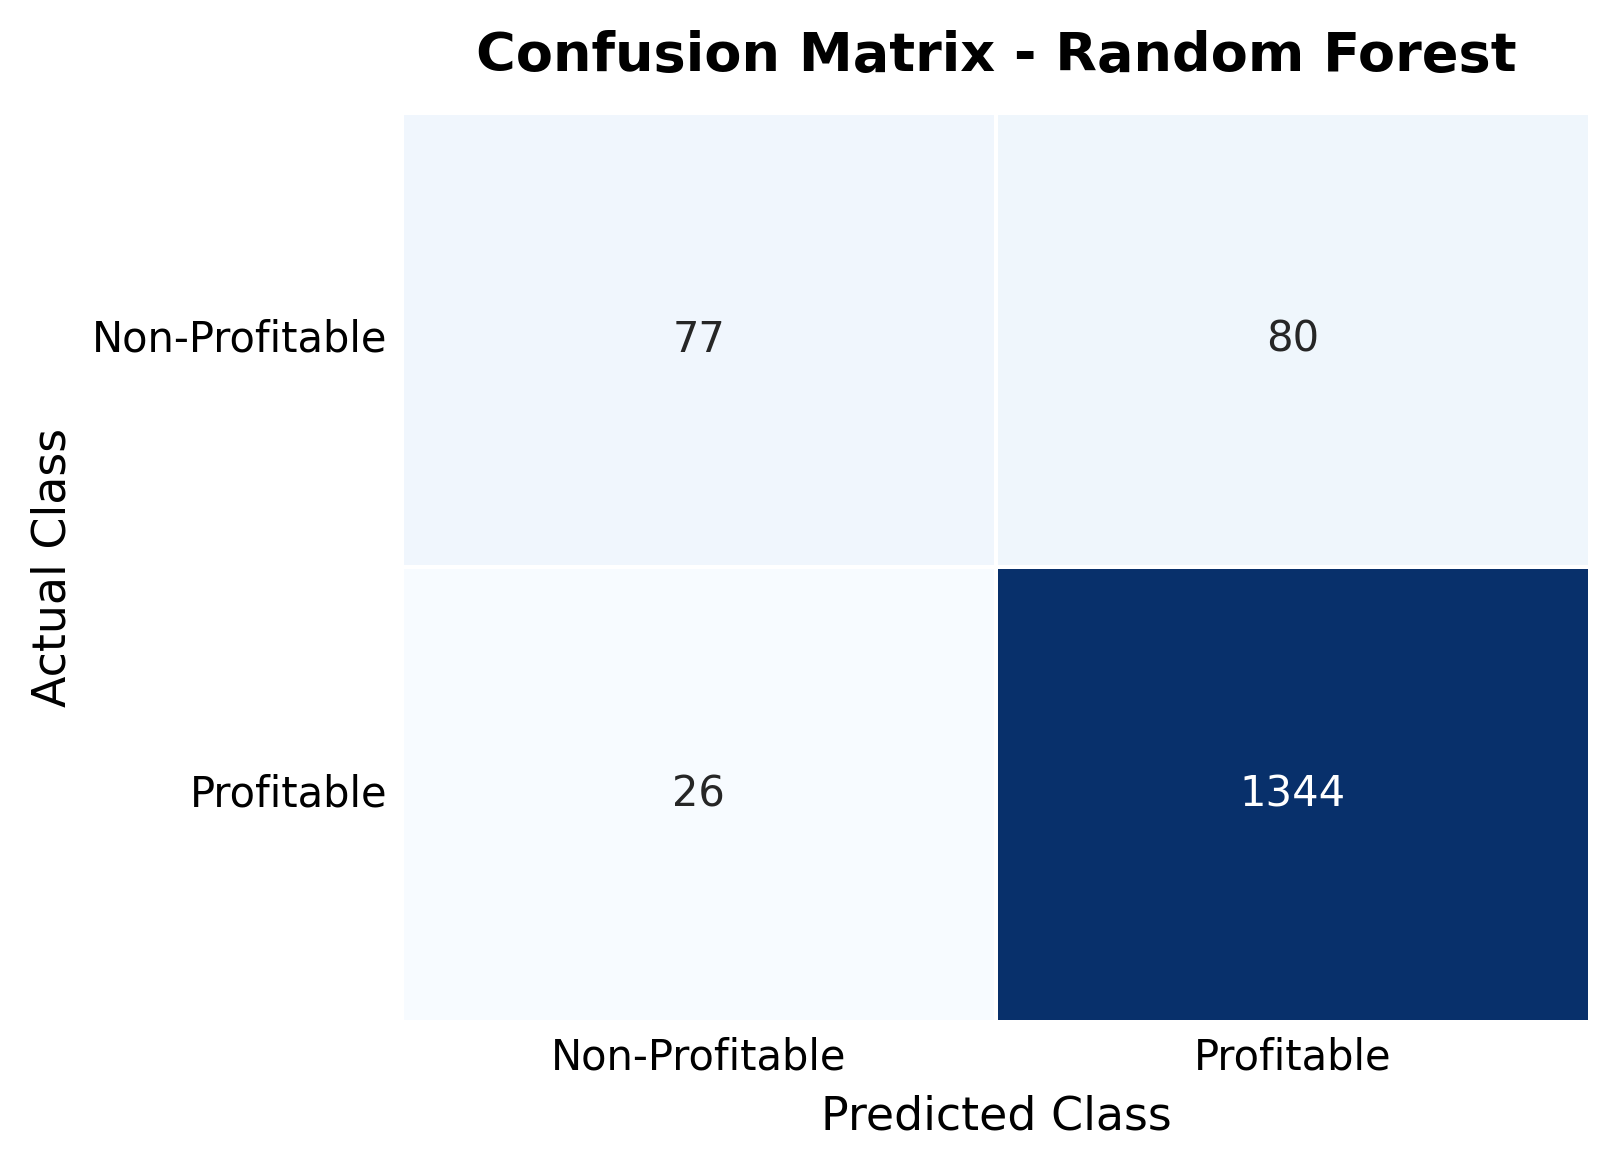

In [129]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_rf = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5.5, 4), dpi=300)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title(
    "Confusion Matrix - Random Forest",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("Actual Class", fontsize=11)

ax.set_xticklabels(["Non-Profitable", "Profitable"], fontsize=10)
ax.set_yticklabels(["Non-Profitable", "Profitable"], fontsize=10, rotation=0)

ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

The model correctly identified 1,344 profitable shipments and 77 non-profitable shipments, while producing relatively few classification errors. The results indicate strong predictive capability, particularly in identifying profitable shipments. Although the dataset is moderately imbalanced toward profitable outcomes, the model was still able to correctly classify a substantial portion of non-profitable shipments, demonstrating its practical usefulness for profitability prediction.


The model is highly effective at identifying both profitable and non-profitable shipments, with very low misclassification rates.

## Logistic Regression

Logistic Regression was used as a baseline model because of its simplicity and interpretability. The model assumes a relatively linear relationship between the input features and the target variable, providing a useful benchmark against which more complex algorithms can be evaluated.


In [103]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score


In [104]:

lr = LogisticRegression(max_iter=1000)


In [105]:
X_train.isna().sum().sort_values(ascending=False).head(10)

month                0
Origin Port_NGLAG    0
Origin Port_NLEIN    0
Origin Port_NLAMS    0
Origin Port_NL       0
Origin Port_NIMGA    0
Origin Port_NGLOS    0
Origin Port_NGLOA    0
Origin Port_NGLKK    0
Origin Port_NAWDH    0
dtype: int64

In [106]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())


In [107]:
lr.fit(X_train, y_train)

c:\Users\thati\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [108]:

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]


In [109]:

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression
Accuracy: 0.8899803536345776
Precision: 0.8974867724867724
Recall: 0.9905109489051095
ROC-AUC: 0.6334115951462178


The model achieved strong performance, with high accuracy, precision, recall, and ROC-AUC values.

## XGBoost

XGBoost was included as an advanced ensemble learning technique known for its strong predictive performance and ability to handle complex patterns within structured datasets. The algorithm sequentially improves model predictions by focusing on observations that are more difficult to classify.


In [110]:

import sys
!{sys.executable} -m pip install xgboost



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [111]:

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score


In [112]:

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)


In [113]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [114]:

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]


In [115]:

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


XGBoost
Accuracy: 0.9364767518009168
Precision: 0.9523809523809523
Recall: 0.9781021897810219
ROC-AUC: 0.9076177414105724


The model achieved very similar performance to Random Forest, confirming that the predictive patterns are consistent across different algorithms.

## Results:

In [116]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results)


                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.889980  0.633412
1        Random Forest  0.930583  0.901002
2              XGBoost  0.936477  0.907618


# ROC Curve

In [118]:
from sklearn.metrics import roc_curve, roc_auc_score

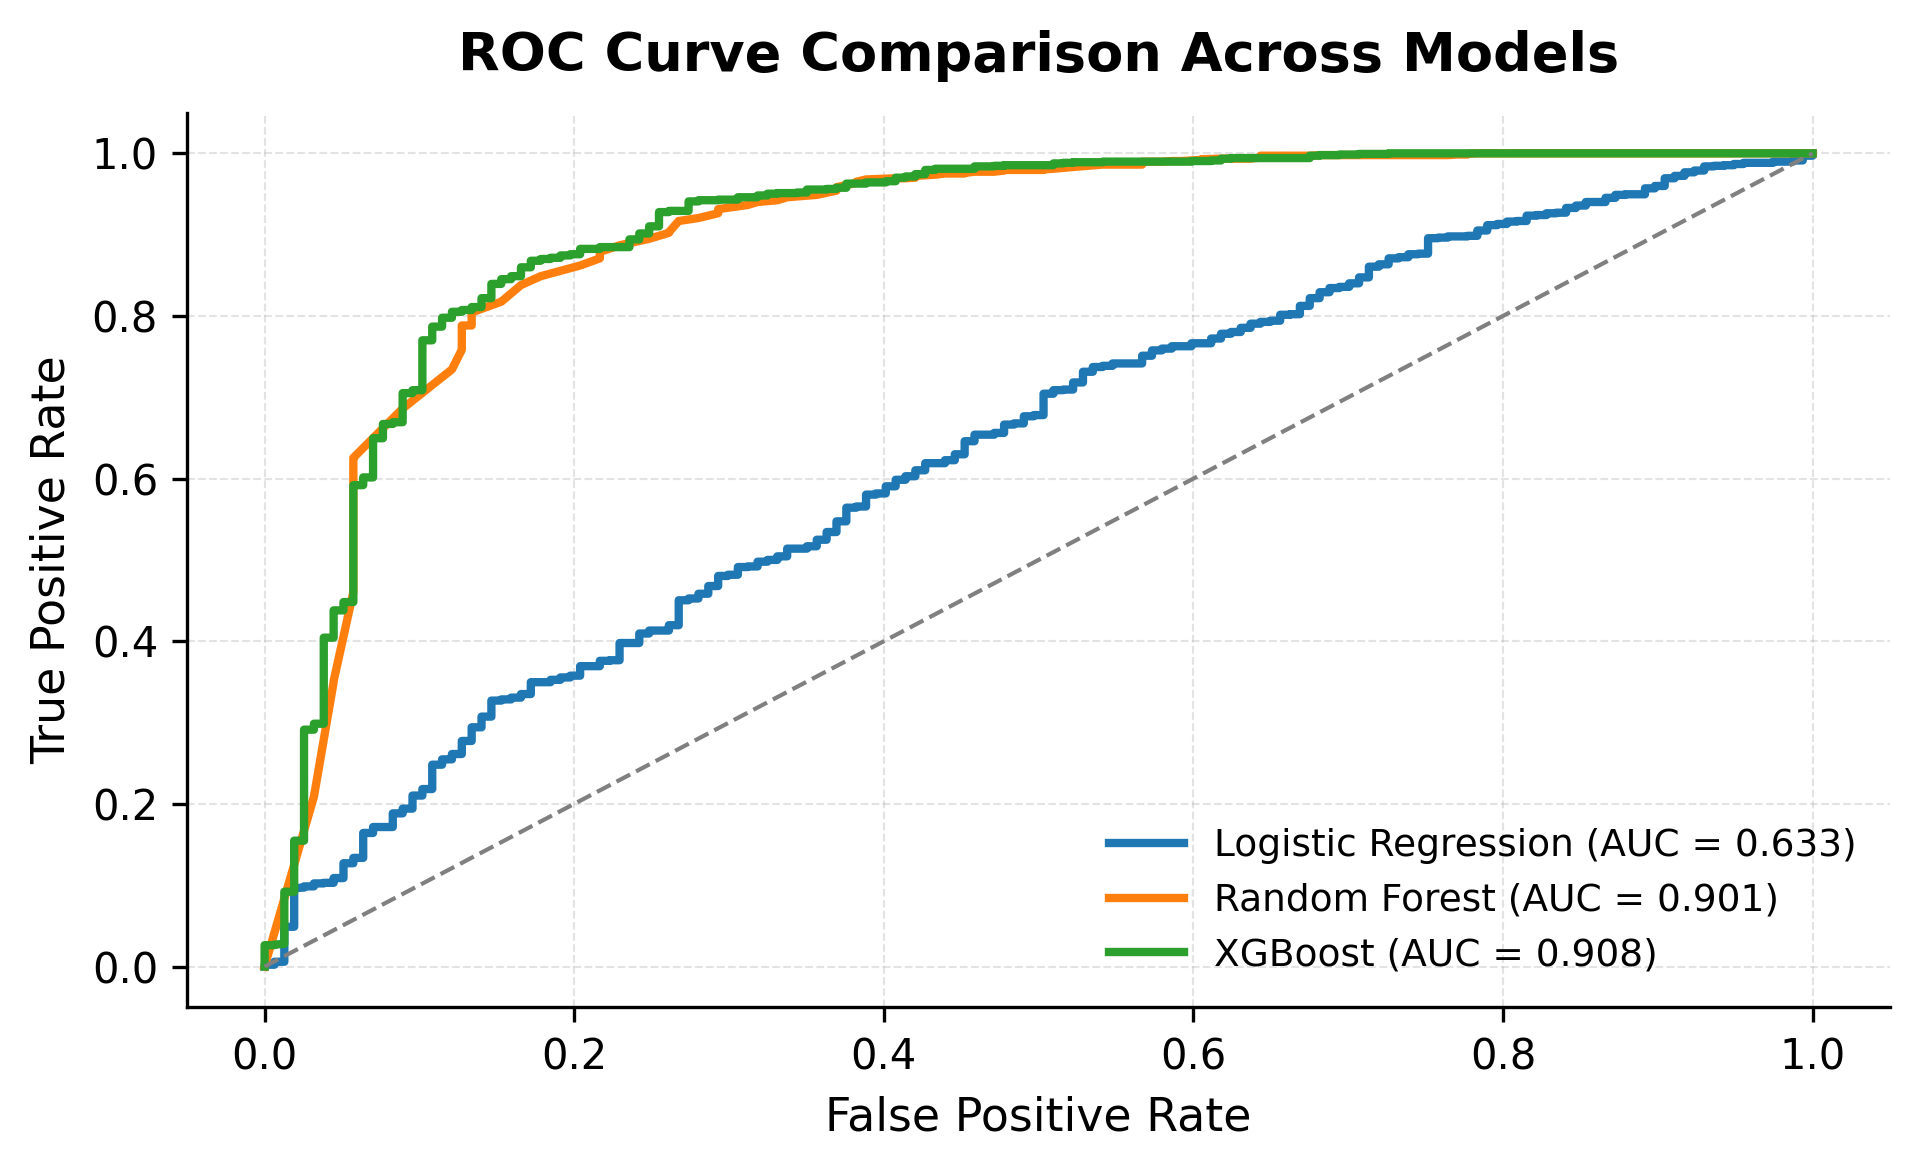

In [122]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ax.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})"
)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob)
ax.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob):.3f})"
)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
ax.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1
)

ax.set_title(
    "ROC Curve Comparison Across Models",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

The results indicate that tree-based models outperformed Logistic Regression. This suggests that shipment profitability is influenced by complex interactions among operational variables that cannot be fully captured through a simple linear relationship. Ensemble models were better able to identify these patterns and generate more accurate predictions.

## Feature importance

To better understand the factors influencing model predictions, feature importance analysis was performed. This analysis identifies the variables that contribute most significantly to profitability classification and provides insight into the operational drivers behind shipment outcomes.


In [ ]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

month                 0.124918
quarter               0.086077
total_process_time    0.081060
Packs                 0.074944
weight_to_volume      0.063570
Weight                0.063003
transit_time          0.049127
Invoice Lines         0.048837
Invoice Headers       0.042760
weekday               0.032077
dtype: float64

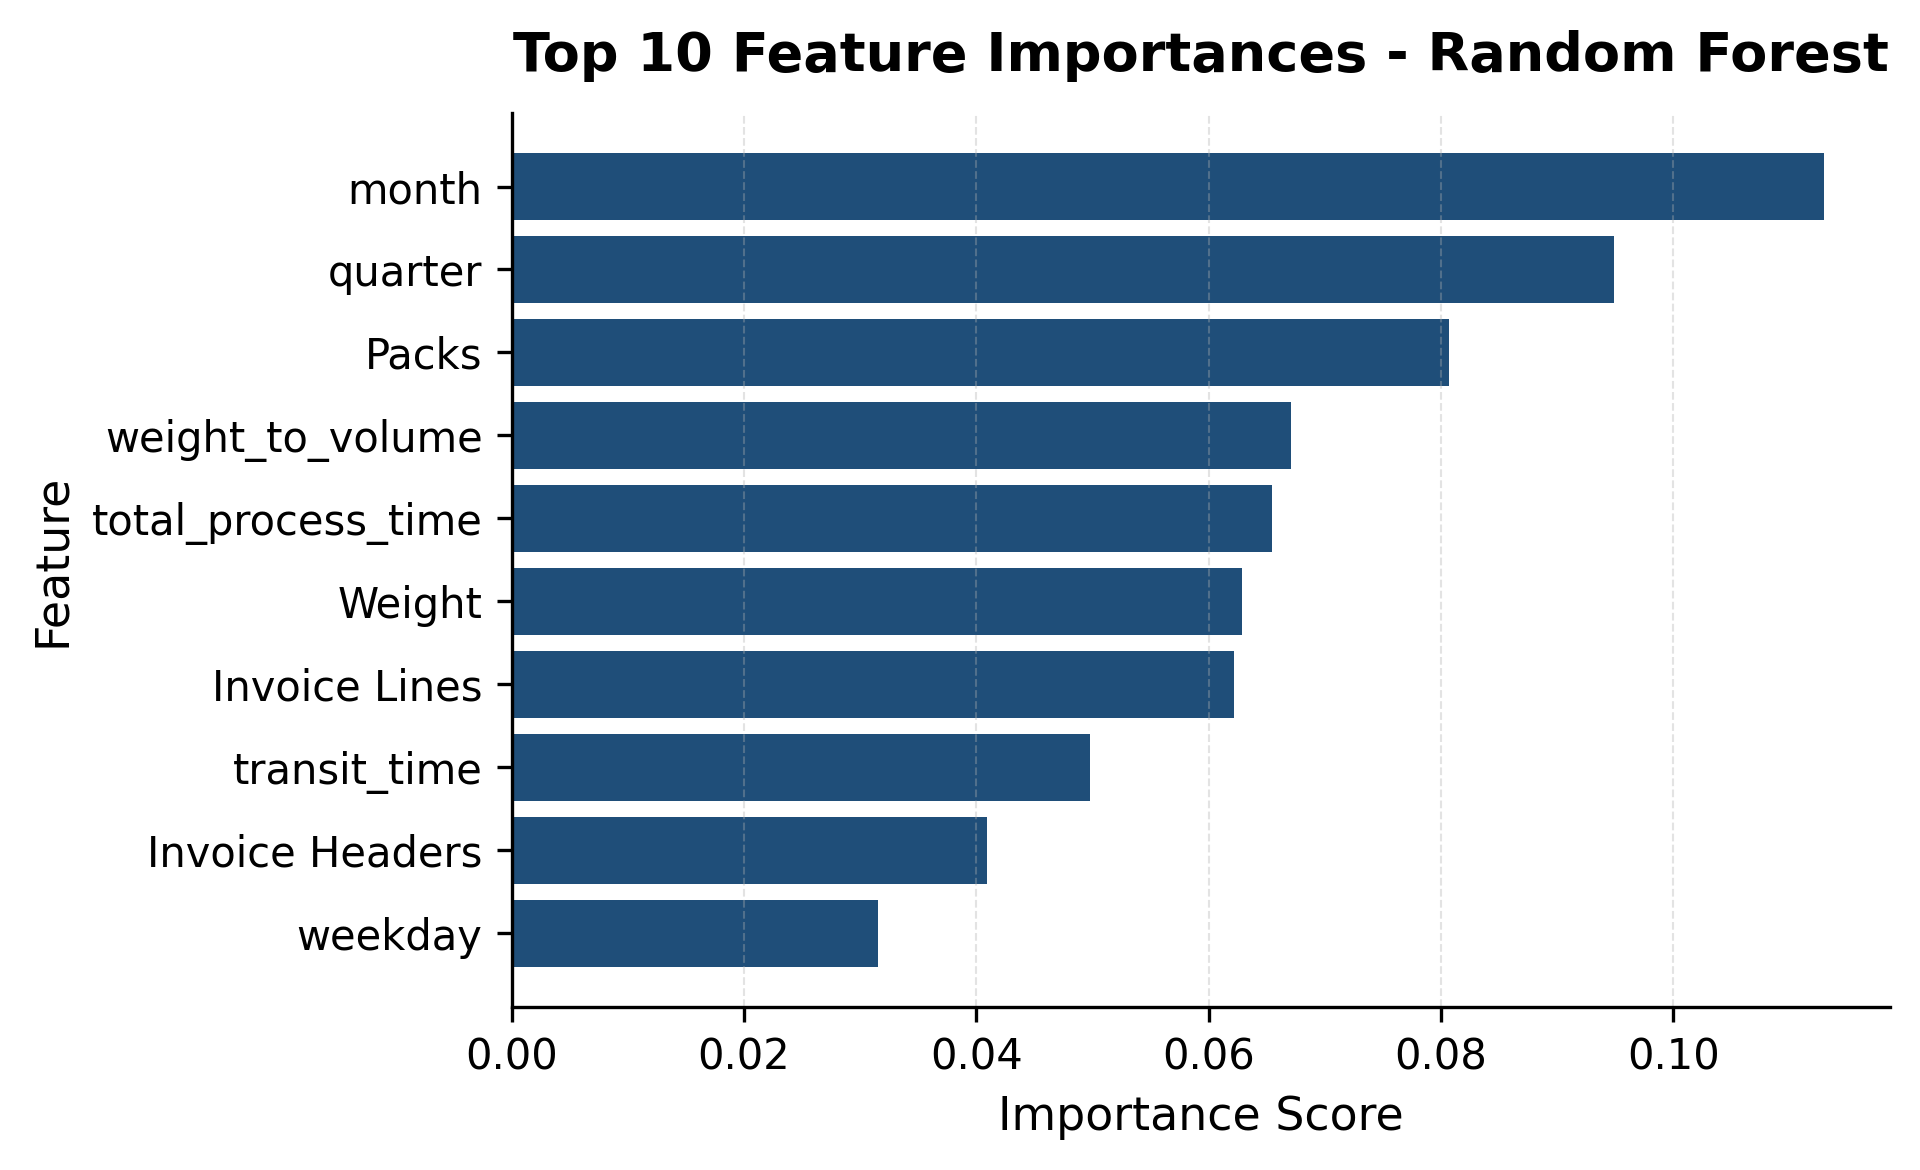

In [124]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_

df_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

df_importance = (
    df_importance
    .sort_values(by="Importance", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=300)

ax.barh(
    df_importance["Feature"],
    df_importance["Importance"],
    color="#1F4E79"
)

ax.invert_yaxis()

ax.set_title(
    "Top 10 Feature Importances - Random Forest",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Importance Score", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

ax.tick_params(axis="both", labelsize=10)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.5,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## Confusion Matrix

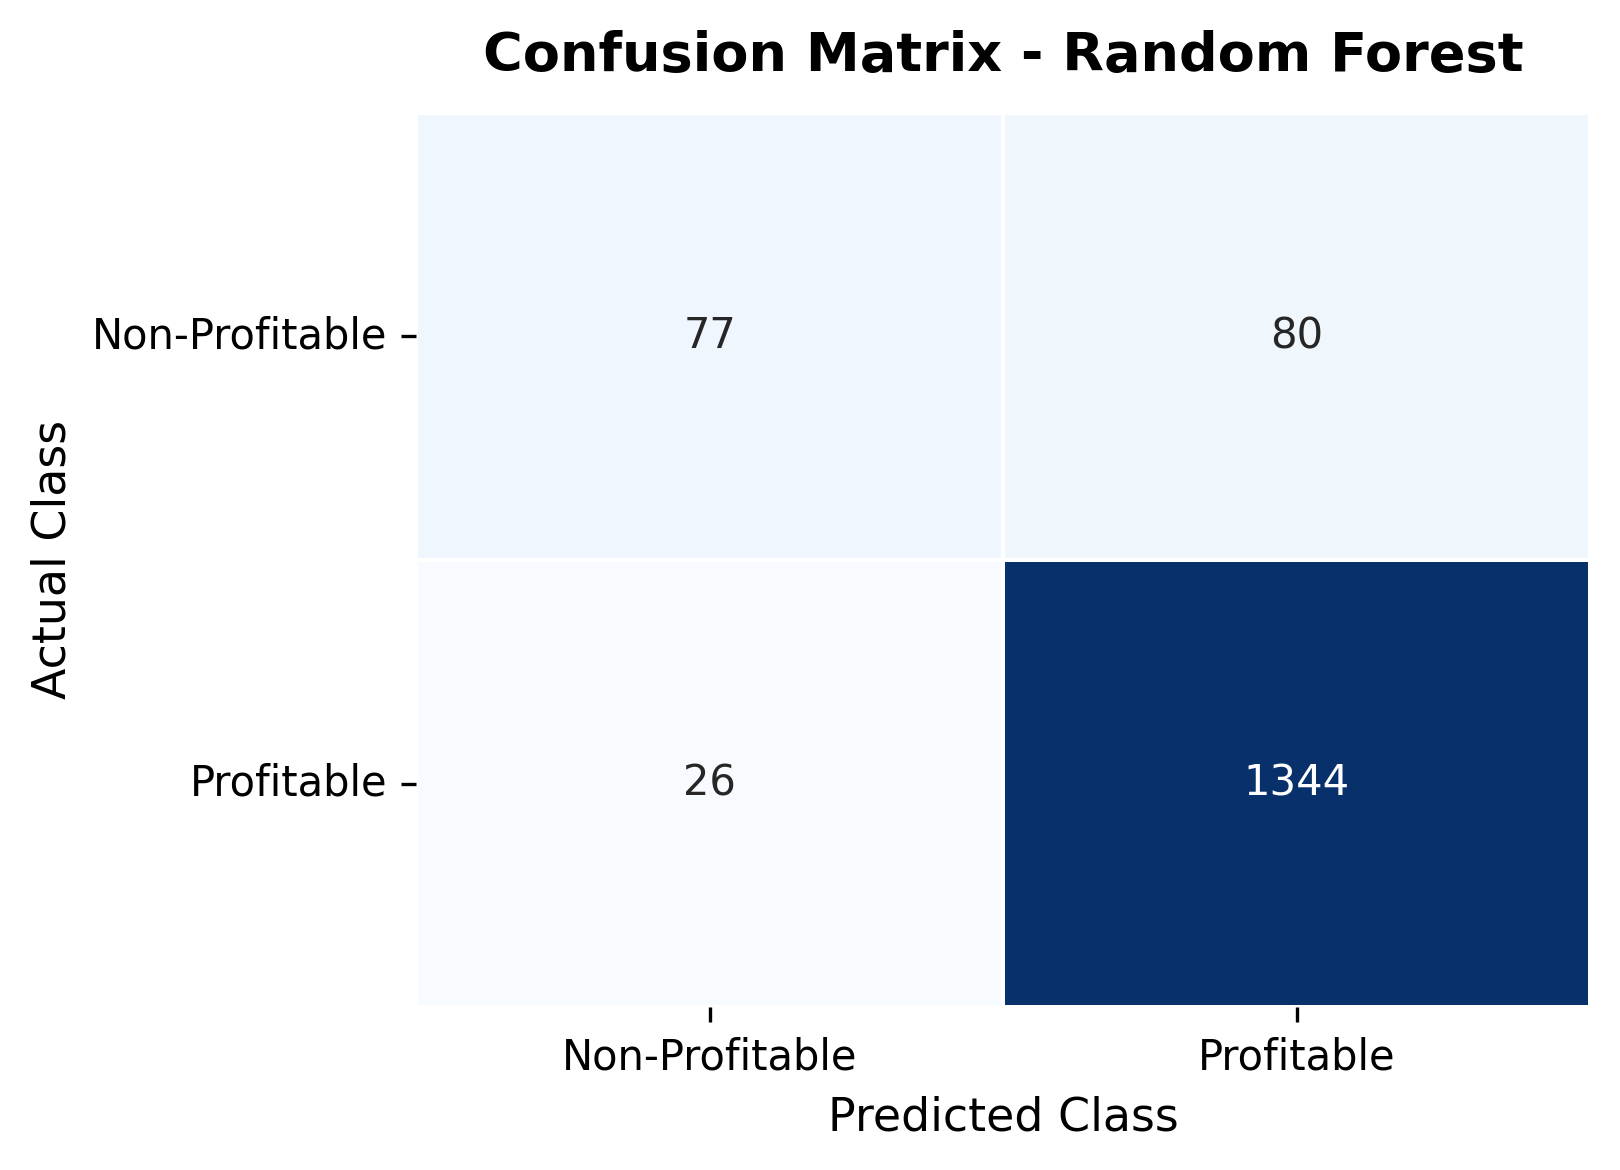

In [131]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(5.5, 4), dpi=300)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title(
    "Confusion Matrix - Random Forest",
    fontsize=13,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("Actual Class", fontsize=11)

ax.set_xticklabels(["Non-Profitable", "Profitable"])
ax.set_yticklabels(["Non-Profitable", "Profitable"], rotation=0)

plt.tight_layout()
plt.show()

## Key Insights

The strong performance gap between Logistic Regression and the ensemble models suggests that profitability is driven by non-linear relationships and interactions between variables, rather than simple linear patterns. The similar performance of Random Forest and XGBoost indicates that the predictive signal in the data is stable and not dependent on a specific model.

## Final Conclusion

This project demonstrated the feasibility of applying machine learning techniques to predict profitability in freight shipments. By combining operational data, engineered features, and advanced predictive models, the study identified key factors associated with successful shipment outcomes. The results suggest that predictive analytics can support more informed operational planning, resource allocation, and business decision-making within logistics organizations.